In [23]:
import glob
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import RegularPolygon, Wedge
from skimage.metrics import structural_similarity as ssim

VIDEO_PATH = "media/videos/test_4.mp4"

In [24]:
import math

def show_debug_grid(win_name, imgs, labels=None, cell_size=(240, 240), pad=6):
    # collect valid
    items = []
    for i, im in enumerate(imgs):
        if im is None:
            continue
        if im.ndim == 2:
            im = cv2.cvtColor(im, cv2.COLOR_GRAY2BGR)
        im = cv2.resize(im, cell_size, interpolation=cv2.INTER_NEAREST)

        if labels is not None and i < len(labels):
            lab = labels[i]

            # normalize to list of lines
            if isinstance(lab, str):
                lines = [lab] if lab else []
            elif isinstance(lab, (list, tuple)):
                lines = [str(x) for x in lab if x is not None and str(x) != ""]
            else:
                lines = [str(lab)]

            # draw top-left multi-line
            y = 22
            for line in lines:
                cv2.putText(im, line, (6, y),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2, cv2.LINE_AA)
                y += 20

        items.append(im)

    if not items:
        return

    n = len(items)
    cols = int(math.ceil(math.sqrt(n)))
    rows = int(math.ceil(n / cols))

    Hc, Wc = cell_size[1], cell_size[0]
    canvas_h = rows * Hc + (rows - 1) * pad
    canvas_w = cols * Wc + (cols - 1) * pad
    canvas = np.zeros((canvas_h, canvas_w, 3), np.uint8)

    for idx, im in enumerate(items):
        r = idx // cols
        c = idx % cols
        y0 = r * (Hc + pad)
        x0 = c * (Wc + pad)
        canvas[y0:y0+Hc, x0:x0+Wc] = im

    cv2.imshow(win_name, canvas)

In [25]:
def rotated_ncc_templates(gray_icon_img, angles=(0,60,120,180,240,300)):
    h, w = gray_icon_img.shape[:2]
    c = (w/2.0, h/2.0)
    out = []
    for a in angles:
        M = cv2.getRotationMatrix2D(c, a, 1.0)
        rot = cv2.warpAffine(gray_icon_img, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REPLICATE)
        rot = cv2.GaussianBlur(rot, (3,3), 0)
        out.append(rot)
    return out

class Template:
    def __init__(self, path, orb):
        self.path = path
        self.name = os.path.splitext(os.path.basename(path))[0]

        self.img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if self.img is None:
            raise FileNotFoundError(path)

        self.ncc_img = cv2.GaussianBlur(self.img, (3, 3), 0)
        self.ncc_h, self.ncc_w = self.ncc_img.shape[:2]
        self.ncc_rots = rotated_ncc_templates(self.img)

        self.kp, self.des = orb.detectAndCompute(self.img, None)
        if self.des is None:
            raise RuntimeError(f"No features in {path}")

        h, w = self.img.shape[:2]
        self.corners = np.float32(
            [[0,0],[w-1,0],[w-1,h-1],[0,h-1]]
        ).reshape(-1,1,2)


In [26]:
def load_templates(folder, orb):
    templates = {}
    for p in glob.glob(os.path.join(folder, "*.*")):
        t = Template(p, orb)
        templates[t.name] = t
    return templates

In [27]:
class MapTile:
    def __init__(self, tile_type="empty", owner="none"):
        self.type = tile_type
        self.owner = owner

        if self.type == "forest":
            self.color = "green"
        elif self.type == "city":
            self.color = "grey"
        elif self.type == "ocean":
            self.color = "blue"
        else:
            self.color = "none"


class Map:
    def __init__(self, hex_size=1.0):
        # Terraforming Mars board shape
        self.row_lengths = [5, 6, 7, 8, 9, 8, 7, 6, 5]
        self.rows = len(self.row_lengths)
        self.hex_size = hex_size

        # (row, col) -> tile type (None, "forest", later "city", "ocean")
        self.tiles = {}

        # (row, col) -> (x, y) center
        self.centers = {}

        self._compute_centers()

    def _compute_centers(self):
        dx = np.sqrt(3) * self.hex_size
        dy = 1.5 * self.hex_size

        max_cols = max(self.row_lengths)

        for r, cols in enumerate(self.row_lengths):
            # center rows horizontally
            row_offset = (max_cols - cols) * dx / 2

            for c in range(cols):
                x = row_offset + c * dx
                y = r * dy
                self.centers[(r, c)] = (x, y)

    def place_tile(self, r, c, tile_type, owner = "none"):
        self.tiles[(r, c)] = MapTile(tile_type, owner)

    def place_forest(self, r, c):
        self.place_tile(r, c, "forest")
    
    def place_city(self, r, c):
        self.place_tile(r, c, "city")
    
    def place_ocean(self, r, c):
        self.place_tile(r, c, "ocean")

    def set_owner(self, r,  c, owner):
        self.tiles[(r, c)].owner = owner

    
    def has_owner(self, r, c):
        return self.tiles[(r, c)] is not None and self.tiles[(r, c)].owner != 'none'

    def nearest_hex(self, x, y):
        return min(
            self.centers.keys(),
            key=lambda k: (self.centers[k][0] - x) ** 2 +
                          (self.centers[k][1] - y) ** 2
        )

    def draw(self, title="Terraforming Mars – Board"):
        fig, ax = plt.subplots(figsize=(8, 8))

        for (r, c), (x, y) in self.centers.items():
            tile = self.tiles.get((r, c))
            if tile is None:
                tile = MapTile()


            hexagon = RegularPolygon(
                (x, y),
                numVertices=6,
                radius=self.hex_size,
                orientation=0.0,
                facecolor="none",
                edgecolor="black",
                linewidth=1
            )
            ax.add_patch(hexagon)

            # left half
            left = Wedge(
                center=(x, y),
                r=self.hex_size,
                theta1=90,
                theta2=270,
                facecolor=tile.color
            )
            left.set_clip_path(hexagon)
            ax.add_patch(left)

            # right half
            right = Wedge(
                center=(x, y),
                r=self.hex_size,
                theta1=-90,
                theta2=90,
                facecolor=tile.color if tile.type == 'ocean' else tile.owner
            )
            right.set_clip_path(hexagon)
            ax.add_patch(right)


        ax.set_aspect("equal")
        ax.autoscale_view()
        ax.invert_yaxis()
        ax.set_title(title)
        ax.axis("off")
        plt.show()

    def shift_to_center(self, target_x, target_y):
        xs = [p[0] for p in self.centers.values()]
        ys = [p[1] for p in self.centers.values()]
        grid_cx = (min(xs) + max(xs)) / 2
        grid_cy = (min(ys) + max(ys)) / 2

        dx = target_x - grid_cx
        dy = target_y - grid_cy

        for k, (x, y) in self.centers.items():
            self.centers[k] = (x + dx, y + dy)

    def tiles_without_owner(self):
        return [(r,c) for (r, c), t in self.tiles.items()
                if t is not None and t.owner == "none" and t.type not in ("empty", "ocean")]



In [28]:
orb = cv2.ORB_create(
    nfeatures=4000,      # default is ~500
    scaleFactor=1.2,
    nlevels=8,
    edgeThreshold=15,    # helps small distant features
    patchSize=31
)

dataset = {
    "board": load_templates("media/photos/board", orb),
    "player_tile": load_templates("media/photos/player_tile", orb),
    "pieces": load_templates("media/photos/pieces", orb),
    "regions": load_templates("media/photos/regions", orb)
}



In [29]:
def iter_video_mapspace(
    video_path,
    orb,
    board_template,
    map_template,
    board_size=(1200, 1200),
    map_size=(800, 800),
    refresh_every=10,
    max_frames=None,
    start_frame=0
):
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
    if not cap.isOpened():
        raise RuntimeError("Could not open video")

    H_frame_to_map = None
    idx = 0

    while True:
        ok, frame = cap.read()
        if not ok:
            break

        idx += 1
        if max_frames is not None and idx > max_frames:
            break

        # Refresh homography periodically (or if we don't have one yet)
        if H_frame_to_map is None or (idx % refresh_every == 0):
            H_new = compute_H_frame_to_map(
                frame, orb,
                board_template=board_template,
                map_template=map_template,
                board_size=board_size,
                map_size=map_size
            )
            if H_new is not None:
                H_frame_to_map = H_new

        # If we still don't have a valid transform, skip
        if H_frame_to_map is None:
            continue

        map_topdown = warp_frame_to_map(frame, H_frame_to_map, map_size=map_size)
        yield idx, frame, map_topdown, H_frame_to_map

    cap.release()


In [30]:
def compute_H_frame_to_map(
    frame_bgr,
    orb,
    board_template,
    map_template,
    board_size=(1200, 1200),
    map_size=(800, 800),
    board_min_good=25,
    map_min_good=20
):
    W, H = board_size
    MW, MH = map_size

    # Detect board in the camera frame
    board_result = detect_template(
        frame_bgr, board_template, orb,
        min_good=board_min_good,
        ratio=0.75,
        ransac_thresh=5.0
    )
    if board_result is None:
        return None

    # Frame -> Board homography (use detected corners)
    board_quad = order_quad(board_result["corners"].reshape(4, 2))
    dst_board = np.float32([[0,0],[W-1,0],[W-1,H-1],[0,H-1]])
    H_frame_to_board = cv2.getPerspectiveTransform(board_quad, dst_board)

    board_topdown = cv2.warpPerspective(frame_bgr, H_frame_to_board, (W, H))

    # Detect map inside board_topdown
    map_result = detect_template(
        board_topdown, map_template, orb,
        min_good=map_min_good,
        ratio=0.75,
        ransac_thresh=5.0
    )
    if map_result is None:
        return None

    # Board -> Map homography
    map_quad_board = order_quad(map_result["corners"].reshape(4, 2))
    dst_map = np.float32([[0,0],[MW-1,0],[MW-1,MH-1],[0,MH-1]])
    H_board_to_map = cv2.getPerspectiveTransform(map_quad_board, dst_map)

    # Compose: Frame -> Map
    H_frame_to_map = H_board_to_map @ H_frame_to_board
    return H_frame_to_map

def warp_frame_to_map(frame_bgr, H_frame_to_map, map_size=(800, 800)):
    MW, MH = map_size
    return cv2.warpPerspective(frame_bgr, H_frame_to_map, (MW, MH))


In [31]:
def detect_template(frame_bgr, template, orb, ratio=0.75, min_good=25, ransac_thresh=5.0):
    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
    kp_fr, des_fr = orb.detectAndCompute(gray, None)
    if des_fr is None or len(kp_fr) < 10:
        return None

    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
    knn = bf.knnMatch(template.des, des_fr, k=2)

    good = []
    for pair in knn:
        if len(pair) != 2:
            continue
        m, n = pair
        if m.distance < ratio * n.distance:
            good.append(m)

    if len(good) < min_good:
        return None

    src = np.float32([template.kp[m.queryIdx].pt for m in good]).reshape(-1,1,2)
    dst = np.float32([kp_fr[m.trainIdx].pt for m in good]).reshape(-1,1,2)

    H, inliers = cv2.findHomography(src, dst, cv2.RANSAC, ransac_thresh)
    if H is None:
        return None

    corners = cv2.perspectiveTransform(template.corners, H)
    inlier_count = int(inliers.sum()) if inliers is not None else 0

    return {"H": H, "corners": corners, "good": len(good), "inliers": inlier_count}

In [32]:
def order_quad(pts4x2):
    # pts4x2: (4,2) float32
    s = pts4x2.sum(axis=1)
    d = np.diff(pts4x2, axis=1).reshape(-1)

    tl = pts4x2[np.argmin(s)]
    br = pts4x2[np.argmax(s)]
    tr = pts4x2[np.argmin(d)]
    bl = pts4x2[np.argmax(d)]

    return np.array([tl, tr, br, bl], dtype=np.float32)

In [33]:
def build_template_variants(base_template, orb, scales=(0.25, 0.5, 1.0)):
    """
    Build multiple scaled versions of `base_template` (Template instance),
    each with its own kp/des/corners.
    Returns list of lightweight template objects with .img/.kp/.des/.corners.
    """
    variants = []

    base = base_template.img  # grayscale
    h0, w0 = base.shape[:2]

    for s in scales:
        w = max(32, int(w0 * s))
        h = max(32, int(h0 * s))

        scaled = cv2.resize(base, (w, h), interpolation=cv2.INTER_AREA)

        for k in range(3):  # 0..300 deg in 60° steps
            angle = 120 * k

            # rotate around center
            M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
            img = cv2.warpAffine(
                scaled, M, (w, h),
                flags=cv2.INTER_LINEAR,
                borderMode=cv2.BORDER_REPLICATE
            )

            kp, des = orb.detectAndCompute(img, None)
            if des is None or len(kp) < 10:
                continue

            corners = np.float32([
                [0, 0],
                [w-1, 0],
                [w-1, h-1],
                [0, h-1]
            ]).reshape(-1, 1, 2)

            variants.append(type("Tmp", (), {
                "img": img,
                "kp": kp,
                "des": des,
                "corners": corners,
                "rot_deg": angle,   # optional but VERY useful for debug
                "scale": s
            })())


    return variants


def match_template_orb_homography(img_bgr, template_or_list, orb,
                                 ratio=0.75, min_good=8,
                                 ransac_thresh=4.0,
                                 min_inliers=10,
                                 area_range=(2500, 120000),
                                 debug=False):
    """
    template_or_list can be:
      - a single Template-like object, or
      - a list of Template-like objects (scaled variants)

    Returns best match across all variants, or None.
    """
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    kp2, des2 = orb.detectAndCompute(gray, None)
    if des2 is None:
        if debug: print("  ❌ No features in current image")
        return None

    bf = cv2.BFMatcher(cv2.NORM_HAMMING)

    templates = template_or_list if isinstance(template_or_list, (list, tuple)) else [template_or_list]

    best = None  # {good,inliers,corners,center,area}

    for ti, template in enumerate(templates):
        knn = bf.knnMatch(template.des, des2, k=2)

        good = []
        for pair in knn:
            if len(pair) == 2:
                m, n = pair
                if m.distance < ratio * n.distance:
                    good.append(m)

        if len(good) < min_good:
            continue

        src_pts = np.float32([template.kp[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
        dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)

        H, inliers = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, ransac_thresh)
        if H is None:
            continue

        inlier_count = int(inliers.sum()) if inliers is not None else 0
        if inlier_count < min_inliers:
            continue

        corners = cv2.perspectiveTransform(template.corners, H)
        pts = corners.reshape(-1, 2)

        h, w = gray.shape[:2]
        margin = 10
        if (pts[:, 0].min() < -margin or pts[:, 0].max() > w + margin or
            pts[:, 1].min() < -margin or pts[:, 1].max() > h + margin):
            continue

        area = abs(cv2.contourArea(pts.astype(np.float32)))
        cy = float(pts[:, 1].mean())
        is_top = (cy < 0.30 * h)  # top 30% of the map image

        min_area = area_range[0] * (0.6 if is_top else 1.0)  # allow smaller projected tiles at top
        if area < min_area or area > area_range[1]:
            continue

        cx = float(pts[:, 0].mean())
        cy = float(pts[:, 1].mean())

        cand = {
            "good": len(good),
            "inliers": inlier_count,
            "corners": corners,
            "center": (cx, cy),
            "area": float(area),
            "variant_idx": ti,
        }

        # pick best by inliers first, then good matches
        if best is None or (cand["inliers"], cand["good"]) > (best["inliers"], best["good"]):
            best = cand

    if debug:
        if best is None:
            print("  ❌ No template variant matched (scale mismatch likely)")
        else:
            print(f"  ✅ Best variant={best['variant_idx']} good={best['good']} inl={best['inliers']} area={best['area']:.0f}")

    return best


def roi_stillness(prev_gray, curr_gray, center_xy, roi_size=140):
    """
    Mean absolute difference in a square ROI around center.
    Lower = more still.
    """
    cx, cy = center_xy
    cx = int(round(cx))
    cy = int(round(cy))

    h, w = curr_gray.shape[:2]
    r = roi_size // 2

    x0 = max(0, cx - r)
    x1 = min(w, cx + r)
    y0 = max(0, cy - r)
    y1 = min(h, cy + r)

    if (x1 - x0) < 10 or (y1 - y0) < 10:
        return 1e9

    a = prev_gray[y0:y1, x0:x1]
    b = curr_gray[y0:y1, x0:x1]

    diff = cv2.absdiff(a, b)
    return float(diff.mean())


def find_homography_frame_to_board(frame_bgr, board_template, orb, board_size,
                                  ratio=0.75, min_good=20, ransac_thresh=5.0,
                                  min_inliers=25):
    """
    Returns H_frame_to_board that warps FRAME -> BOARD coordinates.
    """
    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)

    kp2, des2 = orb.detectAndCompute(gray, None)
    if des2 is None:
        return None

    bf = cv2.BFMatcher(cv2.NORM_HAMMING)
    knn = bf.knnMatch(board_template.des, des2, k=2)

    good = []
    for pair in knn:
        if len(pair) == 2:
            m, n = pair
            if m.distance < ratio * n.distance:
                good.append(m)

    if len(good) < min_good:
        return None

    src_pts = np.float32([board_template.kp[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)

    H_tmpl_to_frame, inliers = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, ransac_thresh)
    if H_tmpl_to_frame is None:
        return None

    inlier_count = int(inliers.sum()) if inliers is not None else 0
    if inlier_count < min_inliers:
        return None

    # Sanity: projected board corners should be inside the frame
    corners_frame = cv2.perspectiveTransform(board_template.corners, H_tmpl_to_frame).reshape(-1, 2)
    hF, wF = gray.shape[:2]
    margin = 20
    if (corners_frame[:, 0].min() < -margin or corners_frame[:, 0].max() > wF + margin or
        corners_frame[:, 1].min() < -margin or corners_frame[:, 1].max() > hF + margin):
        return None

    H_frame_to_tmpl = np.linalg.inv(H_tmpl_to_frame)

    tw = board_template.img.shape[1]
    th = board_template.img.shape[0]
    BW, BH = board_size

    S = np.array([[BW / tw, 0, 0],
                  [0, BH / th, 0],
                  [0, 0, 1]], dtype=np.float64)

    H_frame_to_board = S @ H_frame_to_tmpl
    return H_frame_to_board



In [34]:
def read_frame_at(video_path, frame_idx_1based):
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx_1based - 1)
    ok, frame = cap.read()
    cap.release()
    return frame if ok else None

def estimate_hex_radius_px_from_centers(map_model, sample_limit=200):
    """ Estimate hex 'radius' in pixels from map_model.centers (no hard-coded radius). For pointy-top hex grids: neighbor center distance ~= sqrt(3) * r => r ~= d / sqrt(3) """
    centers = list(map_model.centers.values())
    if len(centers) < 10:
        raise ValueError("Not enough centers to estimate hex radius")
    pts = np.array(centers, dtype=np.float32)
    if len(pts) > sample_limit:
        idx = np.random.choice(len(pts), sample_limit, replace=False)
        pts = pts[idx]
    dists = []
    for i in range(len(pts)):
        dx = pts[:, 0] - pts[i, 0]
        dy = pts[:, 1] - pts[i, 1]
        dd = np.sqrt(dx*dx + dy*dy)
        dd = dd[dd > 1e-3]
        if dd.size == 0:
            continue
        dists.append(float(np.min(dd)))
    if len(dists) < 10:
        raise ValueError("Could not estimate neighbor distance robustly")
    d_med = float(np.median(dists))
    r = d_med / np.sqrt(3.0)
    return float(r)


In [41]:
from collections import deque


def global_motion(prev_gray, curr_gray, step=32):
    a = cv2.GaussianBlur(prev_gray, (5, 5), 0)[::step, ::step]
    b = cv2.GaussianBlur(curr_gray, (5, 5), 0)[::step, ::step]
    return float(cv2.absdiff(a, b).mean())


def roi_mean_absdiff(a_gray, b_gray, center_xy, roi_size=160):
    cx = int(round(center_xy[0]))
    cy = int(round(center_xy[1]))

    h, w = b_gray.shape[:2]
    r = roi_size // 2

    x0 = max(0, cx - r)
    x1 = min(w, cx + r)
    y0 = max(0, cy - r)
    y1 = min(h, cy + r)

    if (x1 - x0) < 10 or (y1 - y0) < 10:
        return 1e9

    diff = cv2.absdiff(a_gray[y0:y1, x0:x1], b_gray[y0:y1, x0:x1])
    return float(diff.mean())



def match_template_orb_homography_precomputed(
    kp2, des2, gray_shape_hw,
    template_variants,
    bf,
    ratio=0.75,
    min_good=8,
    ransac_thresh=4.0,
    min_inliers=10,
    area_range=(2500, 120000),
):
    """
    FAST path: reuse kp2/des2 computed ONCE per frame.
    """
    if des2 is None:
        return None

    h, w = gray_shape_hw
    best = None

    for ti, template in enumerate(template_variants):
        knn = bf.knnMatch(template.des, des2, k=2)

        good = []
        for pair in knn:
            if len(pair) == 2:
                m, n = pair
                if m.distance < ratio * n.distance:
                    good.append(m)

        if len(good) < min_good:
            continue

        src_pts = np.float32([template.kp[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
        dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)

        H, inliers = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, ransac_thresh)
        if H is None:
            continue

        inlier_count = int(inliers.sum()) if inliers is not None else 0
        if inlier_count < min_inliers:
            continue

        # --- Reject matches that cover only a small patch of the template ---
        if inliers is not None:
            mask = inliers.ravel().astype(bool)
            if mask.sum() >= min_inliers:
                src_inl = src_pts[mask].reshape(-1, 2).astype(np.float32)

                # 1) convex-hull coverage (very mild threshold)
                hull = cv2.convexHull(src_inl)
                hull_area = float(cv2.contourArea(hull))
                tmpl_area = float(template.img.shape[0] * template.img.shape[1])
                cov = hull_area / (tmpl_area + 1e-9)

                # 2) elongation via PCA eigenvalues (line-like => huge ratio)
                mu = src_inl.mean(axis=0, keepdims=True)
                X = src_inl - mu
                C = (X.T @ X) / max(1, len(src_inl) - 1)
                eig = np.linalg.eigvalsh(C)  # ascending
                l2 = float(eig[0]) + 1e-9
                l1 = float(eig[1]) + 1e-9
                elong = l1 / l2

                # Reject ONLY when it's both: small coverage AND very line-like
                if cov < 0.10 and elong > 12.0:
                    continue



        corners = cv2.perspectiveTransform(template.corners, H)
        pts = corners.reshape(-1, 2)

        margin = 10
        if (pts[:, 0].min() < -margin or pts[:, 0].max() > w + margin or
            pts[:, 1].min() < -margin or pts[:, 1].max() > h + margin):
            continue

        area = abs(cv2.contourArea(pts.astype(np.float32)))
        cy = float(pts[:, 1].mean())
        is_top = (cy < 0.30 * h)  # top 30% of the map image

        min_area = area_range[0] * (0.6 if is_top else 1.0)  # allow smaller projected tiles at top
        if area < min_area or area > area_range[1]:
            continue
        corners = cv2.perspectiveTransform(template.corners, H)
        pts = corners.reshape(-1, 2)

        rect = cv2.minAreaRect(pts.astype(np.float32))
        angle = rect[2]  # Rotation angle in degrees (-90 to 0 for portrait, 0 to 90 for landscape)

        # Normalize angle to -45 to 45 range
        if angle < -45:
            angle += 90
        elif angle > 45:
            angle -= 90

        # Reject if rotated more than 25 degrees
        # if abs(angle) > 25:
        #     continue

        # # Also check aspect ratio (tilted hexagons become elongated)
        # width, height = rect[1]
        # aspect = max(width, height) / (min(width, height) + 1e-9)
        # if aspect > 1.4:  # Hexagons should be roughly square
        #     continue

        # REPLACE your anchor-based center with this:
        cx, cy = pts.mean(axis=0)  # centroid of the 4 corners (robust)
        cx, cy = float(cx), float(cy)

        cand = {
            "good": len(good),
            "inliers": inlier_count,
            "corners": corners,
            "center": (cx, cy),
            "area": float(area),
            "variant_idx": ti,
        }

        if best is None or (cand["inliers"], cand["good"]) > (best["inliers"], best["good"]):
            best = cand

    return best


def make_snap_cell_fn_from_map(map_model, hysteresis_px=18.0):
    """
    Sticky snapping: keep prev cell unless new cell is clearly closer by hysteresis_px.
    """
    prev_cell = {"rc": None}

    def snap_cell_fn(x, y):
        # naive nearest
        r2, c2 = map_model.nearest_hex(x, y)
        cand_rc = (int(r2), int(c2))
        cand_cx, cand_cy = map_model.centers[cand_rc]

        prev_rc = prev_cell["rc"]
        if prev_rc is not None and prev_rc in map_model.centers:
            prev_cx, prev_cy = map_model.centers[prev_rc]

            d_prev = (x - prev_cx) ** 2 + (y - prev_cy) ** 2
            d_cand = (x - cand_cx) ** 2 + (y - cand_cy) ** 2

            # only switch if candidate is *significantly* closer
            if d_cand > d_prev - (hysteresis_px ** 2):
                cand_rc = prev_rc
                cand_cx, cand_cy = prev_cx, prev_cy

        prev_cell["rc"] = cand_rc
        return cand_rc[0], cand_rc[1], float(cand_cx), float(cand_cy)

    return snap_cell_fn


def dbg_draw_snap(map_bgr, raw_xy, snap_rc, map_model, hex_r_px, corners=None):
    vis = map_bgr.copy()

    rx, ry = int(round(raw_xy[0])), int(round(raw_xy[1]))
    cv2.circle(vis, (rx, ry), 6, (0, 0, 255), -1)  # raw center (red)

    if corners is not None:
        pts = corners.reshape(-1, 2).astype(np.int32)
        cv2.polylines(vis, [pts], True, (0, 255, 255), 2)

    if snap_rc is not None and snap_rc in map_model.centers:
        sx, sy = map_model.centers[snap_rc]
        sx_i, sy_i = int(round(sx)), int(round(sy))
        cv2.circle(vis, (sx_i, sy_i), 6, (0, 255, 0), -1)  # snapped center (green)
        cv2.line(vis, (rx, ry), (sx_i, sy_i), (255, 255, 255), 2)

        # draw the snapped hex outline
        cx, cy = float(sx), float(sy)
        poly = []
        for k in range(6):
            ang = np.deg2rad(60 * k + 30)
            x = cx + hex_r_px * np.cos(ang)
            y = cy + hex_r_px * np.sin(ang)
            poly.append([int(round(x)), int(round(y))])
        cv2.polylines(vis, [np.array(poly, np.int32)], True, (0, 255, 0), 2)

        dx, dy = (raw_xy[0] - sx), (raw_xy[1] - sy)
        cv2.putText(vis, f"raw({rx},{ry})  snap{snap_rc}  d=({dx:+.1f},{dy:+.1f})",
                    (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    return vis

def warp_quad(map_gray, corners_4x1x2, tw, th):
    src = corners_4x1x2.reshape(4, 2).astype(np.float32)
    dst = np.float32([[0,0],[tw-1,0],[tw-1,th-1],[0,th-1]])
    Hp = cv2.getPerspectiveTransform(src, dst)
    return cv2.warpPerspective(map_gray, Hp, (tw, th))

def zncc(a_gray, b_gray, mask=None):
    a = a_gray.astype(np.float32)
    b = b_gray.astype(np.float32)

    if mask is not None:
        m = (mask.astype(np.uint8) > 0)
        if m.sum() < 50:
            return -1.0
        a = a[m]
        b = b[m]

    a = (a - a.mean()) / (a.std() + 1e-6)
    b = (b - b.mean()) / (b.std() + 1e-6)
    return float((a * b).mean())

def blue_score_in_hex(map_bgr, center_xy, hex_r_px):
    cx, cy = int(round(center_xy[0])), int(round(center_xy[1]))
    h, w = map_bgr.shape[:2]

    # build hex mask in full map coords
    poly = []
    for k in range(6):
        ang = np.deg2rad(60 * k + 30)
        x = cx + hex_r_px * np.cos(ang)
        y = cy + hex_r_px * np.sin(ang)
        poly.append([int(round(x)), int(round(y))])
    poly = np.array(poly, np.int32)

    mask = np.zeros((h, w), np.uint8)
    cv2.fillPoly(mask, [poly], 255)

    hsv = cv2.cvtColor(map_bgr, cv2.COLOR_BGR2HSV)
    Hh, Ss, Vv = hsv[..., 0], hsv[..., 1], hsv[..., 2]

    blue = ((Hh >= 85) & (Hh <= 140) & (Ss >= 50) & (Vv >= 50))
    blue_ratio = float(np.mean(blue[mask > 0]))

    # also measure “how uniform” it is (oceans are flat-ish)
    V = Vv[mask > 0].astype(np.float32)
    v_std = float(V.std()) if V.size else 999.0

    return blue_ratio, v_std

def detect_all_tile_placements(
    video_path,
    orb,
    board_template,
    map_template,
    tile_templates,               # dict: {"forest": tmpl, "city": tmpl, "ocean": tmpl}
    board_size=(1200, 1200),
    map_size=(800, 800),
    refresh_every=3,
    max_frames=None,
    ratio=0.75,
    min_good=6,
    min_inliers=6,
    ransac_thresh=5.0,
    area_range=(800, 200000),
    stable_frames=2,
    stable_miss_allow=2,
    min_dwell_sec=0.8,
    max_cell_changes=0,
    center_tol_px=40,
    roi_size=200,
    still_thresh=12.0,
    min_inlier_margin=4,
    min_good_margin=4,
    appear_lookback_sec=0.8,
    appear_thresh=10.0,
    cooldown_sec=1.2,
    snap_cell_fn=None,
    debug=False,
    start_frame=0
):
    if debug:
        cv2.namedWindow("DEBUG", cv2.WINDOW_NORMAL)
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError("Could not open video")
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    min_dwell_frames = int(min_dwell_sec * fps)
    cap.release()

    cooldown_frames = int(cooldown_sec * fps)
    lookback_frames = max(1, int(appear_lookback_sec * fps))

    tile_variants = {name: build_template_variants(tmpl, orb) for name, tmpl in tile_templates.items()}
    bf = cv2.BFMatcher(cv2.NORM_HAMMING)

    def close_px_tile(tile_name, p1, p2):
        tol = center_tol_px * (1.8 if tile_name == "ocean" else 1.0)  # tune 1.4–2.2
        return abs(p1[0] - p2[0]) <= tol and abs(p1[1] - p2[1]) <= tol

    occupied_cells = {name: set() for name in tile_templates.keys()}

    prev_map_gray = None
    gray_history = deque(maxlen=lookback_frames + 1)

    events = []
    candidate = None
    stable_count = 0
    lost_count = 0
    cooldown = 0
    lost_frames_needed = 50
    stable_miss = 0
    cand_first_frame = None
    cell_changes = 0

    CHECK_OCEAN_FREQ = 20
    ocean_checked = 20


    def _label_lines(*xs):
        return [str(x) for x in xs if x is not None and str(x) != ""]

    def _dbg_simple(title, map_topdown, frame_idx, fps, shake, cooldown, lost_count, extra=None):
        if not debug:
            return None
        vis = map_topdown.copy()
        lines = _label_lines(
            title,
            f"frame={frame_idx} t={frame_idx/fps:.2f}s",
            f"shake={shake:.2f} cooldown={cooldown}",
            f"lost={lost_count}/{lost_frames_needed}",
            extra
        )
        show_debug_grid(
            "DEBUG",
            imgs=[vis],
            labels=[lines],
            cell_size=(520, 260),
            pad=8
        )
        key = cv2.waitKey(1) & 0xFF
        if key == ord('p'):
            cv2.waitKey(0)
        elif key == ord('q'):
            cv2.destroyAllWindows()
            return "quit"
        return None

    def _dbg_full(
        title,
        map_topdown, map_gray, prev_map_gray,
        m, tile, second_m,
        tmpl, patch_resized,
        edge_density, ssim_score, variance_ratio,
        shake, still,
        frame_idx, fps,
        dbg_cell_rc,
        stable_count, stable_frames, cooldown
    ):
        if not debug:
            return None

        # ROI crop around detected center
        cx_i = int(round(m["center"][0]))
        cy_i = int(round(m["center"][1]))
        r0 = roi_size // 2
        x0 = max(0, cx_i - r0); x1 = min(map_gray.shape[1], cx_i + r0)
        y0 = max(0, cy_i - r0); y1 = min(map_gray.shape[0], cy_i + r0)

        roi_curr = map_gray[y0:y1, x0:x1]
        roi_prev = prev_map_gray[y0:y1, x0:x1] if prev_map_gray is not None else None

        # snap/geometry view
        hex_r_px = estimate_hex_radius_px_from_centers(map_model)

        if dbg_cell_rc is not None and dbg_cell_rc in map_model.centers:
            vis_snap = dbg_draw_snap(
                map_topdown,
                raw_xy=m["center"],
                snap_rc=dbg_cell_rc,
                map_model=map_model,
                hex_r_px=hex_r_px,
                corners=m["corners"],
            )
            sx, sy = map_model.centers[dbg_cell_rc]
            snap_line = f"cell={dbg_cell_rc} d=({m['center'][0]-sx:+.1f},{m['center'][1]-sy:+.1f})"
        else:
            vis_snap = map_topdown.copy()
            cv2.circle(vis_snap, (cx_i, cy_i), 6, (0, 0, 255), -1)
            snap_line = "cell=None"

        # diff/edges
        diff_img = cv2.absdiff(tmpl, patch_resized)
        tmpl_edges = cv2.Canny(tmpl, 50, 150)
        patch_edges = cv2.Canny(patch_resized, 50, 150)

        if second_m is not None:
            amb_line = f"2nd inl={second_m['inliers']} good={second_m['good']}"
            amb_pass = not (m["inliers"] < second_m["inliers"] + min_inlier_margin and
                            m["good"]   < second_m["good"]   + min_good_margin)
        else:
            amb_line = "2nd: none"
            amb_pass = True

        imgs = [
            vis_snap,
            roi_prev if roi_prev is not None else None,
            roi_curr,
            tmpl,
            patch_resized,
            diff_img,
            tmpl_edges,
            patch_edges,
        ]

        labels = [
            _label_lines(
                f"{title}  tile={tile} v={m['variant_idx']}",
                f"frame={frame_idx} t={frame_idx/fps:.2f}s",
                f"inl={m['inliers']} good={m['good']} area={m['area']:.0f}",
                amb_line,
                f"amb_pass={amb_pass}",
                f"SSIM={ssim_score:.3f} edge={edge_density:.3f} var={variance_ratio:.2f}",
                f"shake={shake:.2f} still={still:.2f}/{still_thresh:.2f}",
                snap_line,
                f"stable={stable_count}/{stable_frames} cooldown={cooldown}",
            ),
            "ROI prev",
            "ROI curr",
            "template",
            "patch",
            "absdiff",
            "tmpl edges",
            "patch edges",
        ]

        show_debug_grid("DEBUG", imgs=imgs, labels=labels, cell_size=(520, 260), pad=8)
        key = cv2.waitKey(1) & 0xFF
        if key == ord('p'):
            cv2.waitKey(0)
        elif key == ord('q'):
            cv2.destroyAllWindows()
            return "quit"
        return None

    for frame_idx, frame, map_topdown, H_frame_to_map in iter_video_mapspace(
        video_path,
        orb,
        board_template,
        map_template,
        board_size=board_size,
        map_size=map_size,
        refresh_every=refresh_every,
        max_frames=max_frames,
        start_frame=start_frame
    ):
        if (frame_idx % 100 == 0):
            print(f"frame: {frame_idx}")

        map_gray = cv2.cvtColor(map_topdown, cv2.COLOR_BGR2GRAY)

        nonblack = np.mean(map_gray > 15)
        if nonblack < 0.35:
            # too dark / bad warp frame
            q = _dbg_simple("REJECT:NONBLACK", map_topdown, frame_idx, fps, 0.0, cooldown, lost_count,
                            extra=f"nonblack={nonblack:.2f}")
            if q == "quit":
                return events
            prev_map_gray = map_gray
            continue

        gray_history.append(map_gray)

        if prev_map_gray is None:
            q = _dbg_simple("INIT", map_topdown, frame_idx, fps, 0.0, cooldown, lost_count, extra="prev_map_gray=None")
            if q == "quit":
                return events
            prev_map_gray = map_gray
            continue

        shake = global_motion(prev_map_gray, map_gray, step=32)

        if cooldown > 0:
            q = _dbg_simple("COOLDOWN", map_topdown, frame_idx, fps, shake, cooldown, lost_count)
            if q == "quit":
                return events
            cooldown -= 1
            prev_map_gray = map_gray
            continue

        kp2, des2 = orb.detectAndCompute(map_gray, None)
        if des2 is None or len(kp2) < 20:
            lost_count += 1
            # if lost_count >= lost_frames_needed:
            #     candidate = None
            #     stable_count = 0
            q = _dbg_simple("REJECT:LOW_KP", map_topdown, frame_idx, fps, shake, cooldown, lost_count,
                            extra=f"kp={0 if kp2 is None else len(kp2)}")
            if q == "quit":
                return events
            prev_map_gray = map_gray
            continue

        scored = []
        for name, variants in tile_variants.items():
            mm = match_template_orb_homography_precomputed(
                kp2, des2, map_gray.shape[:2],
                variants,
                bf,
                ratio=ratio,
                min_good=min_good,
                ransac_thresh=ransac_thresh,
                min_inliers=min_inliers,
                area_range=area_range,
            )
            if mm is not None:
                scored.append((name, mm))

        # ADDED: ORB-free ocean fallback when ORB finds nothing (or finds only non-ocean)
        if not scored and ocean_checked == 0:
            hex_r_px = estimate_hex_radius_px_from_centers(map_model)

            best_rc = None
            best_blue = 0.0
            best_std = 1e9

            # scan all cells, but skip already occupied ocean cells
            for rc, (cx, cy) in map_model.centers.items():
                if rc in occupied_cells["ocean"]:
                    continue

                blue_ratio, v_std = blue_score_in_hex(map_topdown, (cx, cy), hex_r_px)

                # CHANGED/NEW: require very blue + fairly uniform
                if blue_ratio > best_blue and v_std < 35.0:
                    best_blue = blue_ratio
                    best_std = v_std
                    best_rc = rc

            # if strong blue fill detected, create a "pseudo match"
            if best_rc is not None and best_blue >= 0.72:  # tune 0.68–0.80
                cx, cy = map_model.centers[best_rc]

                # corners: simple box around center (just to carry geometry; not used for ORB)
                r = int(round(0.95 * hex_r_px))
                corners = np.float32([
                    [cx - r, cy - r],
                    [cx + r, cy - r],
                    [cx + r, cy + r],
                    [cx - r, cy + r],
                ]).reshape(4, 1, 2)

                # push as if it was an ORB result
                scored.append(("ocean", {
                    "good": 999,
                    "inliers": 999,
                    "corners": corners,
                    "center": (float(cx), float(cy)),
                    "area": float((2*r) * (2*r)),
                    "variant_idx": 0
                }))
            
            ocean_checked = CHECK_OCEAN_FREQ

        if not scored:
            ocean_checked -= 1
            lost_count += 1

            if candidate is not None:
                stable_miss += 1
                if stable_miss <= stable_miss_allow:
                    q = _dbg_simple("MISS:KEEP_CAND", map_topdown, frame_idx, fps, shake, cooldown, lost_count,
                                    extra=f"stable_miss={stable_miss}/{stable_miss_allow}")
                    if q == "quit":
                        return events
                    prev_map_gray = map_gray
                    continue

            # too many misses -> drop
            candidate = None
            stable_count = 0
            stable_miss = 0

            q = _dbg_simple("REJECT:NO_MATCH", map_topdown, frame_idx, fps, shake, cooldown, lost_count)
            if q == "quit":
                return events
            prev_map_gray = map_gray
            continue


        lost_count = 0

        scored.sort(key=lambda x: (x[1]["inliers"], x[1]["good"]), reverse=True)
        tile, m = scored[0]
        second_m = scored[1][1] if len(scored) > 1 else None

        y_norm = float(m["center"][1]) / float(map_gray.shape[0])
        is_top = (y_norm < 0.30)

        edge_thr = 0.05 * (0.50 if is_top else 1.0)   # 0.04 on top, 0.05 elsewhere
        ssim_thr = 0.20 * (0.90 if is_top else 1.0)   # optional: 0.18 on top
        var_lo, var_hi = (0.1, 0.75) if is_top else (0.1, 0.65) 

        # Prepare patch/template early so debug can show on ALL gates
        tmpl = tile_variants[tile][m["variant_idx"]].img
        th, tw = tmpl.shape[:2]
        patch = warp_quad(map_gray, m["corners"], tw, th)
        patch_resized = cv2.resize(patch, (tmpl.shape[1], tmpl.shape[0]))

        patch_edges = cv2.Canny(patch_resized, 50, 150)
        edge_density = np.count_nonzero(patch_edges) / patch_edges.size
        ssim_score = ssim(tmpl, patch_resized)

        patch_variance = np.var(patch_resized)
        tmpl_variance = np.var(tmpl)
        variance_ratio = patch_variance / (tmpl_variance + 1e-6)

        still = roi_mean_absdiff(prev_map_gray, map_gray, m["center"], roi_size=roi_size)

        dbg_cell_rc = None
        if snap_cell_fn is not None:
            out = snap_cell_fn(*m["center"])
            dbg_cell_rc = (int(out[0]), int(out[1]))
            if dbg_cell_rc is not None:
                if dbg_cell_rc in occupied_cells.values():
                    q = _dbg_simple(
                        f"REJECT:OCCUPIED {dbg_cell_rc}",
                        map_topdown, frame_idx, fps,
                        shake, cooldown, lost_count
                    )
                    if q == "quit":
                        return events
                    prev_map_gray = map_gray
                    continue

        # ---- Gate 1: ambiguity ----
        if second_m is not None:
            amb_reject = (m["inliers"] < second_m["inliers"] + min_inlier_margin and
                          m["good"]   < second_m["good"]   + min_good_margin)
            if amb_reject:
                q = _dbg_full("REJECT:AMBIG", map_topdown, map_gray, prev_map_gray,
                              m, tile, second_m, tmpl, patch_resized,
                              edge_density, ssim_score, variance_ratio,
                              shake, still, frame_idx, fps, dbg_cell_rc,
                              stable_count, stable_frames, cooldown)
                if q == "quit":
                    return events
                prev_map_gray = map_gray
                continue

        # ---- Gate 2: edges ----
        # (ocean slightly lower accepted edge density)
        # edge_thr = 0.04 if tile == "ocean" else 0.05
        # if edge_density < edge_thr:
        #     q = _dbg_full("REJECT:EDGE", map_topdown, map_gray, prev_map_gray,
        #                   m, tile, second_m, tmpl, patch_resized,
        #                   edge_density, ssim_score, variance_ratio,
        #                   shake, still, frame_idx, fps, dbg_cell_rc,
        #                   stable_count, stable_frames, cooldown)
        #     if q == "quit":
        #         return events
        #     prev_map_gray = map_gray
        #     continue



        # ---- Gate 3: SSIM/variance (tile-specific) ----
        ocean_passed = True
        blue_ratio = None
        if tile == "ocean":
            # warp the COLOR patch (same corners)
            src = m["corners"].reshape(4, 2).astype(np.float32)
            dst = np.float32([[0,0],[tw-1,0],[tw-1,th-1],[0,th-1]])
            Hp = cv2.getPerspectiveTransform(src, dst)
            patch_bgr = cv2.warpPerspective(map_topdown, Hp, (tw, th))

            hsv = cv2.cvtColor(patch_bgr, cv2.COLOR_BGR2HSV)
            Hh, Ss, Vv = hsv[...,0], hsv[...,1], hsv[...,2]

            # blue-ish (tune if needed)
            blue = ((Hh >= 85) & (Hh <= 140) & (Ss >= 50) & (Vv >= 50))
            blue_ratio = float(np.mean(blue))

            # OPTIONAL: suppress false oceans on neutral/grey areas
            # (if you find it too strict, lower 0.08 -> 0.05)
            edges_good = True
            pe = (patch_edges > 0).astype(np.uint8)

            # A) reject if edges are overly concentrated near one side (typical board seam / warp slip)
            ys, xs = np.where(pe)
            if xs.size > 0:
                x = xs / (pe.shape[1] - 1)
                side_frac = max(
                    (x > 0.78).mean(),  # right band
                    (x < 0.22).mean()   # left band
                )
                if side_frac > 0.60:   # tune 0.55–0.70
                    edges_good=False  # REJECT:OCEAN_EDGE_SIDE_DOMINANT

            # B) reject if there is a single dominant long straight edge (board border / seam)
            lines = cv2.HoughLinesP(
                patch_edges, 1, np.pi/180,
                threshold=35,
                minLineLength=int(0.45 * pe.shape[1]),
                maxLineGap=10
            )
            if lines is not None:
                max_len = 0.0
                for x1, y1, x2, y2 in lines[:, 0, :]:
                    L = ((x2 - x1)**2 + (y2 - y1)**2) ** 0.5
                    if L > max_len:
                        max_len = L
                if max_len > 0.65 * pe.shape[1]:   # tune 0.60–0.75
                    edges_good = False  # REJECT:OCEAN_DOMINANT_LINE

            ocean_passed = (
                edges_good and
                ssim_score >= ssim_thr and          # slightly more forgiving
                edge_density >= 0.035 and       # slightly more forgiving
                0.20 < variance_ratio < 2.0 and # slightly wider
                m["inliers"] >= 5 and
                m["good"] >= 8 and
                (blue_ratio is not None and blue_ratio >= 0.65)  # <-- NEW: must be blue
            )
        else:
            # city/forest tighter variance band
            if ssim_score < ssim_thr or edge_density < edge_thr or not (0.1 < variance_ratio < 0.65):
                reason = "REJECT:SSIM" if ssim_score < ssim_thr else ("REJECT:EDGE" if edge_density < edge_thr else "REJECT:VAR")
                q = _dbg_full(reason, map_topdown, map_gray, prev_map_gray,
                              m, tile, second_m, tmpl, patch_resized,
                              edge_density, ssim_score, variance_ratio,
                              shake, still, frame_idx, fps, dbg_cell_rc,
                              stable_count, stable_frames, cooldown)
                if q == "quit":
                    return events
                prev_map_gray = map_gray
                continue

        # ---- Gate 4: general combined band (keep your existing logic) ----
        passed = (ssim_score >= ssim_thr and edge_density >= edge_thr and 0.1 < variance_ratio < 3.0) or ocean_passed
        if not passed or not ocean_passed:
            q = _dbg_full("REJECT:COMBINED", map_topdown, map_gray, prev_map_gray,
                          m, tile, second_m, tmpl, patch_resized,
                          edge_density, ssim_score, variance_ratio,
                          shake, still, frame_idx, fps, dbg_cell_rc,
                          stable_count, stable_frames, cooldown)
            if q == "quit":
                return events
            prev_map_gray = map_gray
            continue

        # ---- Gate 5: stillness ----
        if still > still_thresh:
            q = _dbg_full("REJECT:STILL", map_topdown, map_gray, prev_map_gray,
                          m, tile, second_m, tmpl, patch_resized,
                          edge_density, ssim_score, variance_ratio,
                          shake, still, frame_idx, fps, dbg_cell_rc,
                          stable_count, stable_frames, cooldown)
            if q == "quit":
                return events
            candidate = None
            stable_count = 0
            prev_map_gray = map_gray
            continue


        # ---- Gate 6: Temporal appearance check (tile must be APPEARING, not static) ----
        if len(gray_history) >= 2:
            # Get frame from lookback period
            lookback_idx = min(len(gray_history) - 1, lookback_frames)
            lookback_gray = gray_history[0] if lookback_idx > 0 else prev_map_gray
            
            # Warp the same corners from old frame
            old_patch = warp_quad(lookback_gray, m["corners"], tw, th)
            old_patch_resized = cv2.resize(old_patch, (tmpl.shape[1], tmpl.shape[0]))
            
            # Calculate temporal change
            temporal_diff = cv2.absdiff(old_patch_resized, patch_resized).mean()
            
            # Tile should be APPEARING - require significant temporal change
            # For ocean: lower threshold since it's low-texture
            temporal_thresh = 1.5 if tile == "ocean" else 5.0
            
            if temporal_diff < temporal_thresh:
                q = _dbg_full("REJECT:ALREADY_PRESENT", map_topdown, map_gray, prev_map_gray,
                              m, tile, second_m, tmpl, patch_resized,
                              edge_density, ssim_score, variance_ratio,
                              shake, still, frame_idx, fps, dbg_cell_rc,
                              stable_count, stable_frames, cooldown)
                if debug:
                    print(f"❌ REJECT: Already present (temporal_diff={temporal_diff:.1f} < {temporal_thresh})")
                if q == "quit":
                    return events
                candidate = None
                stable_count = 0
                prev_map_gray = map_gray
                continue



        # Show ACCEPT frame too (so you see what “good” looks like)
        q = _dbg_full("ACCEPT", map_topdown, map_gray, prev_map_gray,
                      m, tile, second_m, tmpl, patch_resized,
                      edge_density, ssim_score, variance_ratio,
                      shake, still, frame_idx, fps, dbg_cell_rc,
                      stable_count, stable_frames, cooldown)
        
        # Plot accepted detection with matplotlib
        import matplotlib.pyplot as plt
        
        # Prepare visualization images
        cx_i = int(round(m["center"][0]))
        cy_i = int(round(m["center"][1]))
        r0 = roi_size // 2
        x0 = max(0, cx_i - r0); x1 = min(map_gray.shape[1], cx_i + r0)
        y0 = max(0, cy_i - r0); y1 = min(map_gray.shape[0], cy_i + r0)
        
        roi_curr = map_gray[y0:y1, x0:x1]
        roi_prev = prev_map_gray[y0:y1, x0:x1] if prev_map_gray is not None else np.zeros_like(roi_curr)
        
        diff_img = cv2.absdiff(tmpl, patch_resized)
        tmpl_edges = cv2.Canny(tmpl, 50, 150)
        patch_edges = cv2.Canny(patch_resized, 50, 150)
        
        # Create visualization with detection overlay
        hex_r_px = estimate_hex_radius_px_from_centers(map_model)
        if dbg_cell_rc is not None and dbg_cell_rc in map_model.centers:
            vis_snap = dbg_draw_snap(
                map_topdown,
                raw_xy=m["center"],
                snap_rc=dbg_cell_rc,
                map_model=map_model,
                hex_r_px=hex_r_px,
                corners=m["corners"],
            )
        else:
            vis_snap = map_topdown.copy()
            cv2.circle(vis_snap, (cx_i, cy_i), 6, (0, 0, 255), -1)
        
        # Convert BGR to RGB for matplotlib
        vis_snap_rgb = cv2.cvtColor(vis_snap, cv2.COLOR_BGR2RGB)
        
        if debug:
            # Create figure
            fig, axes = plt.subplots(2, 4, figsize=(16, 8))
            fig.suptitle(f'ACCEPTED: {tile} @ {frame_idx/fps:.2f}s | cell={dbg_cell_rc} | '
                        f'inl={m["inliers"]} good={m["good"]} | '
                        f'SSIM={ssim_score:.3f} edge={edge_density:.3f} var={variance_ratio:.2f} still={still:.2f}',
                        fontsize=14, fontweight='bold', color='green')
            
            # Row 1
            axes[0, 0].imshow(vis_snap_rgb)
            axes[0, 0].set_title(f'Detection Overlay\nStable: {stable_count}/{stable_frames}')
            axes[0, 0].axis('off')
            
            axes[0, 1].imshow(roi_prev, cmap='gray')
            axes[0, 1].set_title('ROI Previous Frame')
            axes[0, 1].axis('off')
            
            axes[0, 2].imshow(roi_curr, cmap='gray')
            axes[0, 2].set_title('ROI Current Frame')
            axes[0, 2].axis('off')
            
            axes[0, 3].imshow(tmpl, cmap='gray')
            axes[0, 3].set_title(f'Template (variant {m["variant_idx"]})')
            axes[0, 3].axis('off')
            
            # Row 2
            axes[1, 0].imshow(patch_resized, cmap='gray')
            axes[1, 0].set_title('Detected Patch\n(Warped)')
            axes[1, 0].axis('off')
            
            axes[1, 1].imshow(diff_img, cmap='hot')
            axes[1, 1].set_title(f'Template Difference\nMean: {diff_img.mean():.1f}')
            axes[1, 1].axis('off')
            
            axes[1, 2].imshow(tmpl_edges, cmap='gray')
            axes[1, 2].set_title(f'Template Edges')
            axes[1, 2].axis('off')
            
            axes[1, 3].imshow(patch_edges, cmap='gray')
            axes[1, 3].set_title(f'Patch Edges\nDensity: {edge_density:.3f}')
            axes[1, 3].axis('off')
            
            plt.tight_layout()
            plt.show(block=False)
            plt.pause(0.1)  # Allow display to update
            
            if q == "quit":
                plt.close('all')
                return events


        appear = None

        cand = {
            "tile": tile,
            "frame_idx": frame_idx,
            "time_sec": frame_idx / fps,
            "pos_map_xy": m["center"],
            "corners_map": m["corners"],
            "inliers": m["inliers"],
            "good_matches": m["good"],
            "area": m["area"],
            "stillness": still,
            "appear": appear,
            "H_frame_to_map": H_frame_to_map
        }

        cand["raw_center"] = m["center"]

        if snap_cell_fn is not None:
            out = snap_cell_fn(*m["center"])
            if len(out) == 2:
                r, c = out
                cand["cell_rc"] = (int(r), int(c))
            else:
                r, c, cx, cy = out
                cand["cell_rc"] = (int(r), int(c))
                cand["pos_map_xy"] = (float(cx), float(cy))
        else:
            cand["cell_rc"] = None

        # Check if cell changed (tile moving between cells)
        cell_changed = False
        if candidate is not None and candidate.get("cell_rc") is not None and cand.get("cell_rc") is not None:
            same_tile = (candidate["tile"] == tile)
            same_cell = (candidate["cell_rc"] == cand["cell_rc"])
            
            if same_tile and not same_cell:
                # require a real move (not just boundary jitter)
                prev_rc = candidate["cell_rc"]
                curr_rc = cand["cell_rc"]

                prev_cx, prev_cy = map_model.centers[prev_rc]
                curr_cx, curr_cy = map_model.centers[curr_rc]

                move_px = ((curr_cx - prev_cx)**2 + (curr_cy - prev_cy)**2) ** 0.5

                # tune: 0.35–0.55 of hex radius works well
                hex_r_px = estimate_hex_radius_px_from_centers(map_model)
                move_thr = (0.70 if tile == "ocean" else 0.45) * hex_r_px

                if move_px >= move_thr:
                    cell_changed = True
                    if debug:
                        print(f"🔄 Tile moved: {prev_rc} -> {curr_rc} (move_px={move_px:.1f} thr={move_thr:.1f})")
                    
        # Calculate if same place
        same_place = False
        if candidate is not None and candidate.get("cell_rc") is not None and cand.get("cell_rc") is not None:
            same_place = (candidate["cell_rc"] == cand["cell_rc"]) or close_px_tile(tile, candidate["pos_map_xy"], cand["pos_map_xy"])
        elif candidate is not None:
            same_place = close_px_tile(tile, candidate["pos_map_xy"], cand["pos_map_xy"])


        raw_move_px = 0.0
        if candidate is not None:
            px, py = candidate["raw_center"]
            cx, cy = m["center"]
            raw_move_px = ((cx - px)**2 + (cy - py)**2) ** 0.5

        # if tile is still sliding, DO NOT count stability
        # if raw_move_px > 6.0:   # tune: 5–8 px works well
        #     candidate = cand
        #     stable_count = 1
        #     #cand_first_frame = frame_idx
        #     prev_map_gray = map_gray
        #     continue

        # Update candidate and stability counter
        if candidate is None or candidate["tile"] != tile or not same_place:
            candidate = cand
            stable_count = 1
            cand_first_frame = frame_idx
            cell_changes = 0
            if debug:
                print(f"🆕 New candidate: {tile} at cell {cand.get('cell_rc')}")
        elif cell_changed:
            # same tile candidate, moved -> update its position/cell and restart stability+dwell
            candidate = cand
            stable_count = 1
            cand_first_frame = frame_idx
            cell_changes += 1
            if debug:
                print(f"🔄 moved -> re-anchor at {cand.get('cell_rc')} (cell_changes={cell_changes})")



        else:
            # Same detection at same cell - increment stability
            if (cand["inliers"], cand["good_matches"]) > (candidate["inliers"], candidate["good_matches"]):
                candidate = cand
            stable_count += 1
            if debug:
                print(f"📊 Stability: {stable_count}/{stable_frames} at cell {candidate.get('cell_rc')}")

        dwell_ok = (cand_first_frame is not None) and ((frame_idx - cand_first_frame) / fps >= min_dwell_sec)
        cell_ok = (cell_changes <= max_cell_changes)


        stable_frames_tile = 2 if (tile == "ocean" or is_top) else stable_frames
        if stable_count >= stable_frames_tile and (frame_idx - cand_first_frame) >= min_dwell_frames and cell_changes <= max_cell_changes:
            
            # RECALCULATE final position on current frame
            scored_final = []
            for name, variants in tile_variants.items():
                mg = 5 if name == "ocean" else min_good
                mi = 4 if name == "ocean" else min_inliers

                mm = match_template_orb_homography_precomputed(
                    kp2, des2, map_gray.shape[:2],
                    variants,
                    bf,
                    ratio=ratio,
                    min_good=mg,        # CHANGED
                    ransac_thresh=ransac_thresh,
                    min_inliers=mi,     # CHANGED
                    area_range=area_range,
                )
                if mm is not None:
                    scored_final.append((name, mm))
            
            # Get best match for candidate's tile type
            final_match = None
            final_tile = candidate["tile"]
            is_ocean_blue = (final_tile == "ocean" and candidate.get("inliers", 0) >= 900)
            
            for tile_name, match in scored_final:
                if tile_name == final_tile:
                    if final_match is None or \
                       (match["inliers"], match["good"]) > (final_match["inliers"], final_match["good"]):
                        final_match = match
            
            if final_match is None:
                if is_ocean_blue:
                    # accept candidate as final (it was already validated by blue gate + stability)
                    final_match = {
                        "corners": candidate["corners_map"],
                        "center": candidate["raw_center"],  # or candidate["pos_map_xy"] if you prefer
                        "inliers": candidate["inliers"],
                        "good": candidate["good_matches"],
                        "area": candidate["area"],
                    }
                else:
                    if debug:
                        print(f"❌ Lost tile at finalization")
                    candidate = None
                    stable_count = 0
                    cand_first_frame = None
                    cell_changes = 0
                    prev_map_gray = map_gray
                    continue

            # Get FINAL cell position with recalculated detection
            if snap_cell_fn is not None:
                r2, c2 = map_model.nearest_hex(final_match["center"][0], final_match["center"][1])
                final_cell_rc = (int(r2), int(c2))
                final_pos_xy = final_match["center"]

                # if len(out) == 2:
                #     r, c = out
                #     final_cell_rc = (int(r), int(c))
                #     final_pos_xy = final_match["center"]
                # else:
                #     r, c, cx, cy = out
                #     final_cell_rc = (int(r), int(c))
                #     final_pos_xy = (float(cx), float(cy))
            else:
                final_cell_rc = None
                final_pos_xy = final_match["center"]
            
            # Debug: show if position changed from tracked candidate
            if debug and final_cell_rc != candidate.get("cell_rc"):
                print(f"🎯 Final recalc: {candidate.get('cell_rc')} -> {final_cell_rc}")
            
            # Check duplicates with FINAL position
            if final_cell_rc is not None:
                if final_cell_rc in occupied_cells[final_tile]:
                    if debug:
                        print(f"❌ Duplicate at final position {final_cell_rc}")
                    candidate = None
                    stable_count = 0
                    cand_first_frame = None
                    cell_changes = 0
                    cooldown = int(0.5 * fps)
                    prev_map_gray = map_gray
                    continue
            
            # Create event with FINAL recalculated position
            final_event = {
                "tile": final_tile,
                "frame_idx": frame_idx,
                "time_sec": frame_idx / fps,
                "pos_map_xy": final_pos_xy,
                "corners_map": final_match["corners"],
                "inliers": final_match["inliers"],
                "good_matches": final_match["good"],
                "area": final_match["area"],
                "stillness": still,
                "appear": None,
                "H_frame_to_map": H_frame_to_map,
                "cell_rc": final_cell_rc,
            }
            
            events.append(final_event)

            if final_cell_rc is not None:
                occupied_cells[final_tile].add(final_cell_rc)

            print(f"✅ {final_tile} placed @ {final_event['time_sec']:.2f}s pos={final_pos_xy} cell={final_cell_rc}")

            candidate = None
            stable_count = 0
            cand_first_frame = None
            cell_changes = 0
            cooldown = cooldown_frames

        prev_map_gray = map_gray

    return events

In [42]:
MW = 800
hex_size_px = MW / (9 * 1.5)
#map_model = Map(hex_size=hex_size_px)
def make_pixel_map(map_size_wh):
    W, H = map_size_wh
    # grid extents in "hex_size units":
    # x span: (max_cols-1)*sqrt(3) = 8*sqrt(3)
    # y span: (rows-1)*1.5 = 12
    sx = W / (8*np.sqrt(3) + 2.0)   # +2 for left/right radius margin
    sy = H / (12.0 + 2.0)           # +2 for top/bottom radius margin
    hex_size_px = float(min(sx, sy))

    m = Map(hex_size=hex_size_px)
    m.shift_to_center(W * 0.5, H * 0.5)
    return m

map_model = make_pixel_map((800, 800))

tile_templates={
        "forest": dataset["pieces"]["forest"],
        "city":  dataset["pieces"]["city"],
        "ocean": dataset["pieces"]["ocean"],
    }

snap_cell_fn = make_snap_cell_fn_from_map(map_model)

cv2.destroyAllWindows()

events = detect_all_tile_placements(
    VIDEO_PATH,
    orb,
    dataset["board"]["board"],
    dataset["regions"]["map"],
    tile_templates,
    snap_cell_fn=snap_cell_fn,
    debug=False,
    refresh_every=5,
    start_frame=0,
    appear_thresh=5.0,
    appear_lookback_sec=0.3,
    stable_frames =5,
    still_thresh=13.0,
    max_cell_changes=2,
    min_dwell_sec=0,
    stable_miss_allow=35
)


frame: 100
✅ forest placed @ 5.20s pos=(293.0195007324219, 551.220703125) cell=(6, 2)
frame: 200
frame: 300
frame: 400
frame: 500
✅ city placed @ 17.33s pos=(353.07513427734375, 478.0108947753906) cell=(5, 3)
frame: 600
frame: 700
✅ ocean placed @ 26.27s pos=(507.3522033691406, 477.9600830078125) cell=(5, 5)
frame: 800
frame: 900
frame: 1000
frame: 1100
✅ forest placed @ 37.00s pos=(487.86322021484375, 569.2105102539062) cell=(6, 4)
frame: 1200
✅ ocean placed @ 40.97s pos=(302.3633728027344, 390.09320068359375) cell=(4, 3)
frame: 1300
frame: 1400
frame: 1500
frame: 1600
frame: 1700
frame: 1800
frame: 1900
frame: 2000
✅ forest placed @ 69.77s pos=(358.17010498046875, 154.3238525390625) cell=(1, 2)
frame: 2100
frame: 2200


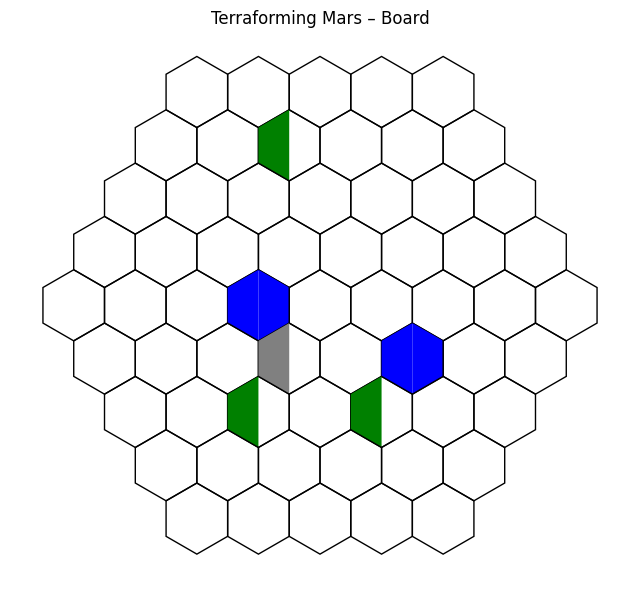

In [43]:
#print(events[2])

for evt in events:
    r, c= evt["cell_rc"]
    map_model.place_tile(r, c, evt["tile"])

map_model.draw()


🔍 Searching for cube on FOREST tile (6,2)
   Start delay: 600ms
   Will watch: 359 frames (~12.0s)
   Required hits: 4/8

   Frame   0: - No detection


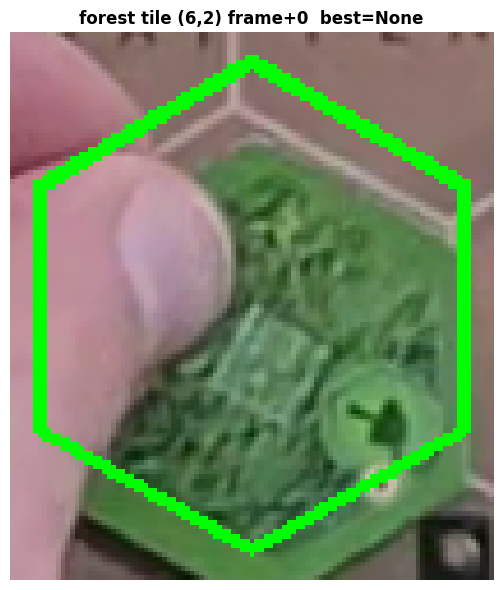

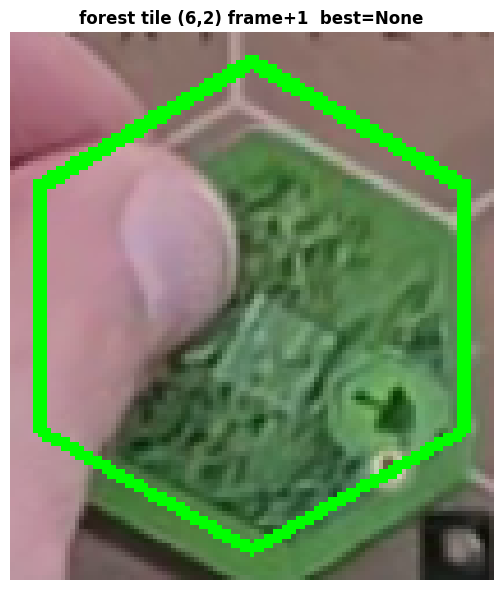

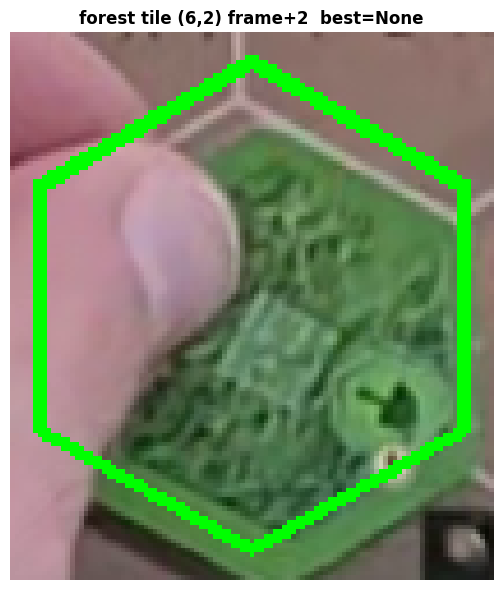

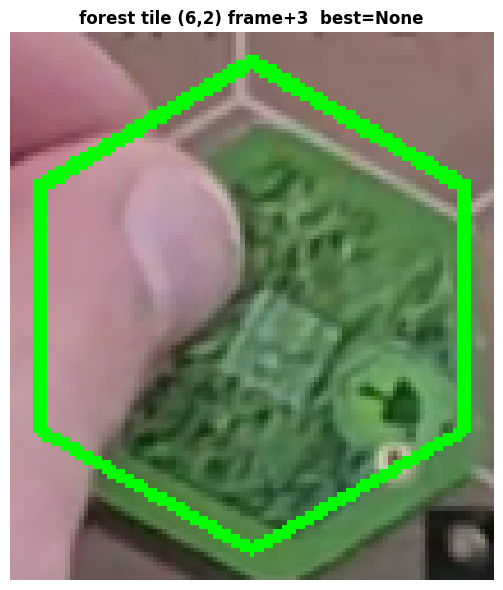

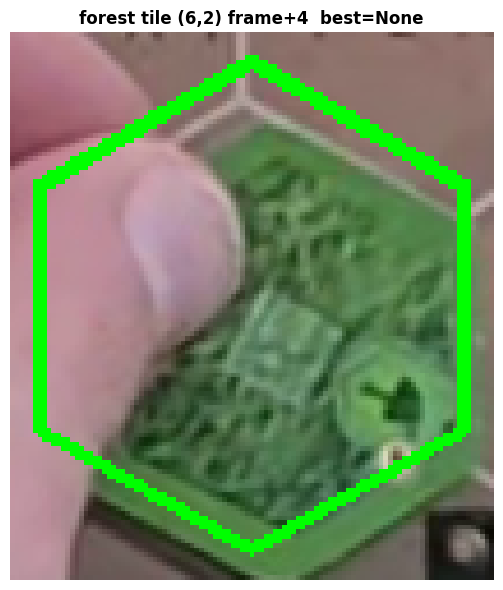

   Frame  10: - No detection


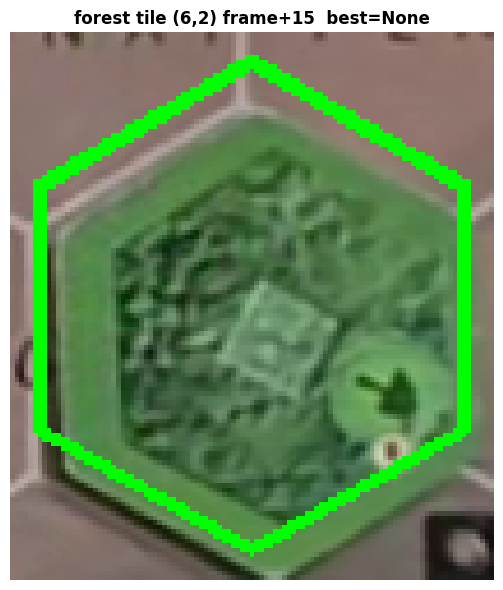

   Frame  20: - No detection
   Frame  30: - No detection


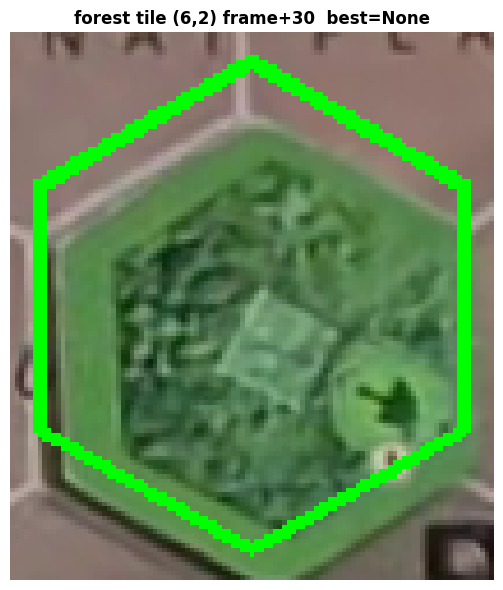

   Frame  40: - No detection


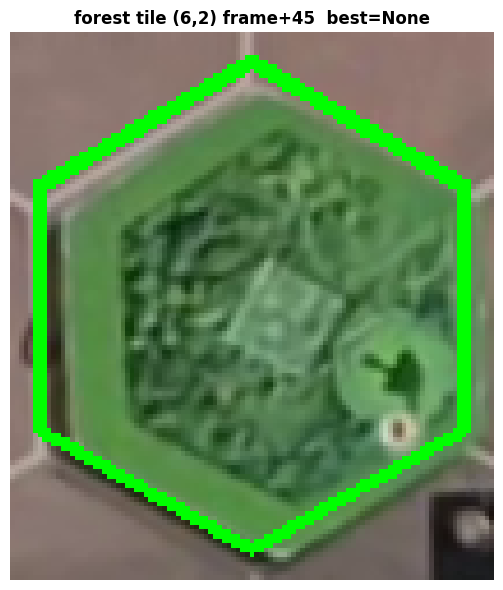

   Frame  50: - No detection
   Frame  60: - No detection


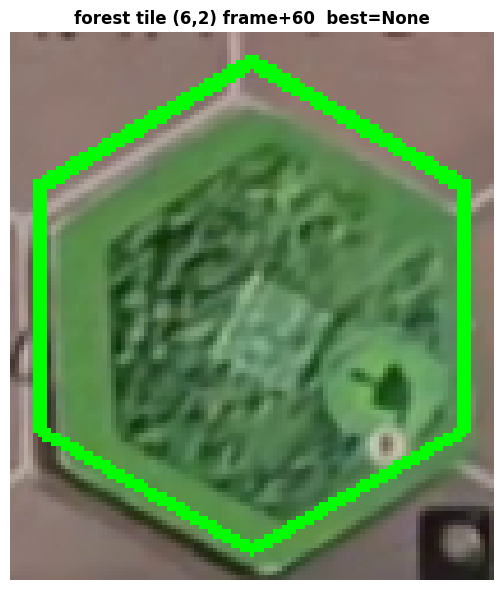

   Frame 117: ✓ RED   score=   5.5 area= 552 @ (48,74)
   Frame 118: ✓ RED   score=   7.0 area= 650 @ (46,76)
   Frame 119: ✓ RED   score=   9.5 area= 675 @ (46,76)
   Frame 120: ✓ RED   score=   9.9 area= 675 @ (46,76)


/tmp/ipykernel_330682/1551053889.py:498: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/pipi/fer/erasmus/computer vision/CV_Project2/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


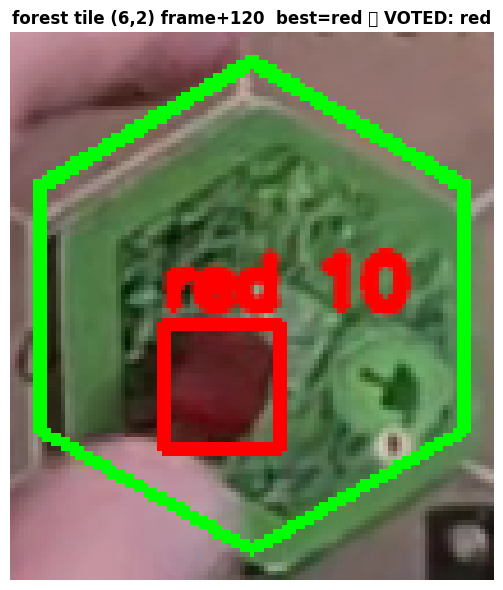


✅ CUBE DETECTED: RED
   Tile: forest (6,2)
   Time: 9.80s (frame 120/121)
   Detections: 4/121 frames
   BBox: (294, 555, 25, 27)

cube_evt: {'rc': (6, 2), 'color': 'red', 't_sec': 9.800566666666667, 'bbox_map': (294, 555, 25, 27), 'tile_center_map_xy': (312.61319836228836, 551.3583803474598)}

🔍 Searching for cube on CITY tile (5,3)
   Start delay: 600ms
   Will watch: 359 frames (~12.0s)
   Required hits: 4/8

   Frame   0: - No detection


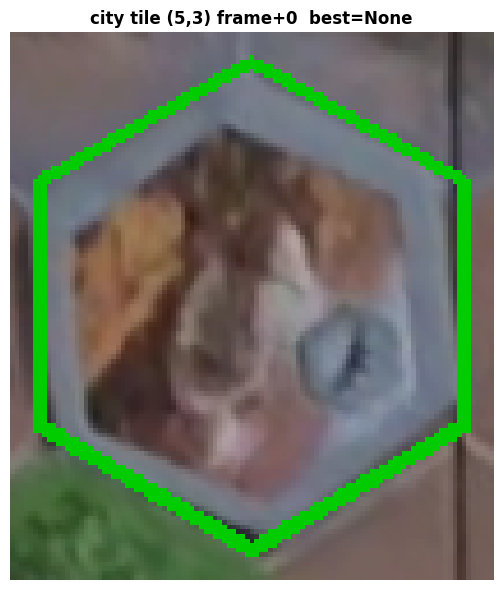

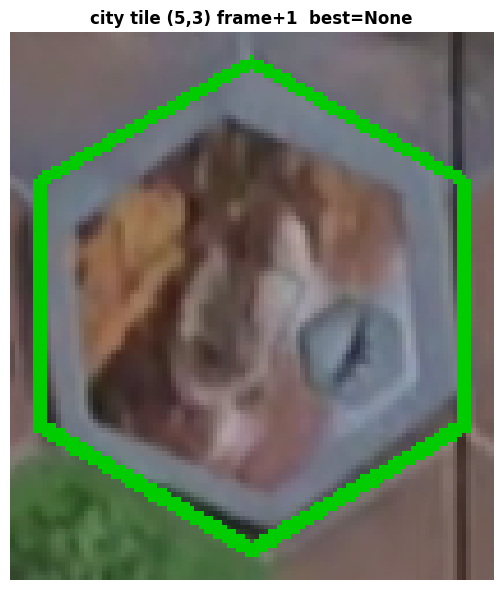

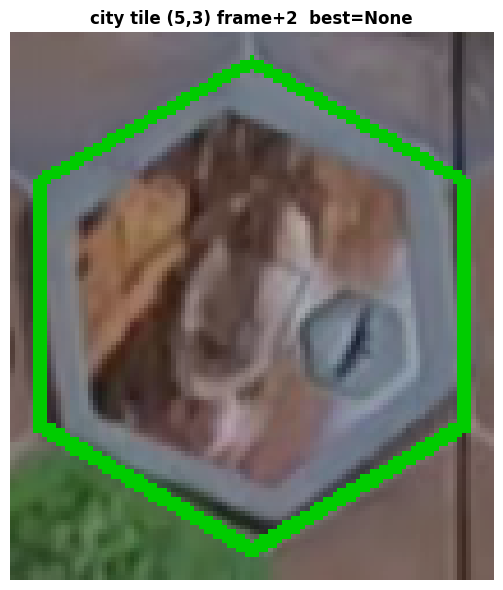

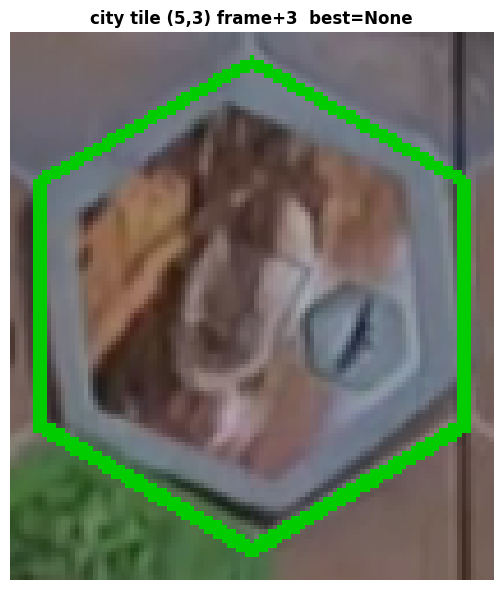

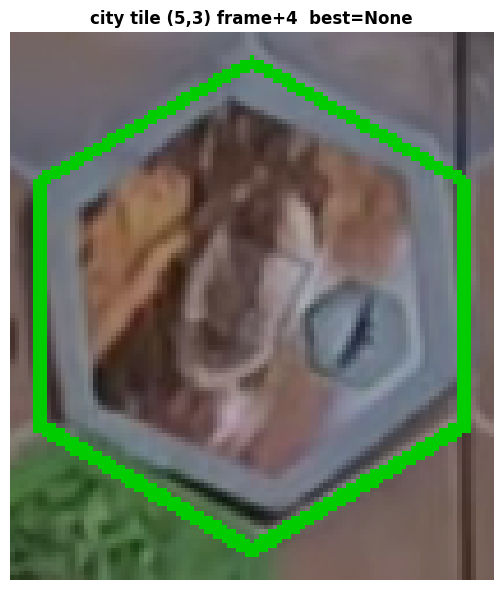

   Frame  10: - No detection


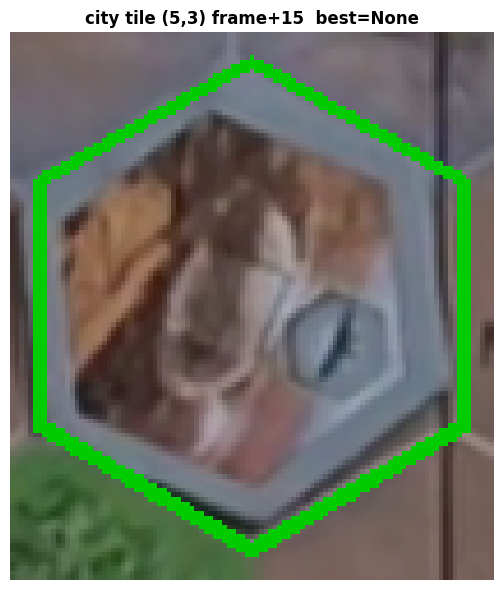

   Frame  20: - No detection
   Frame  30: - No detection


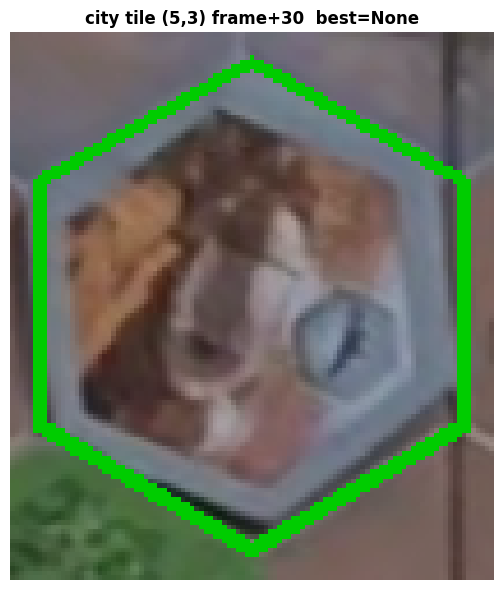

   Frame  40: - No detection


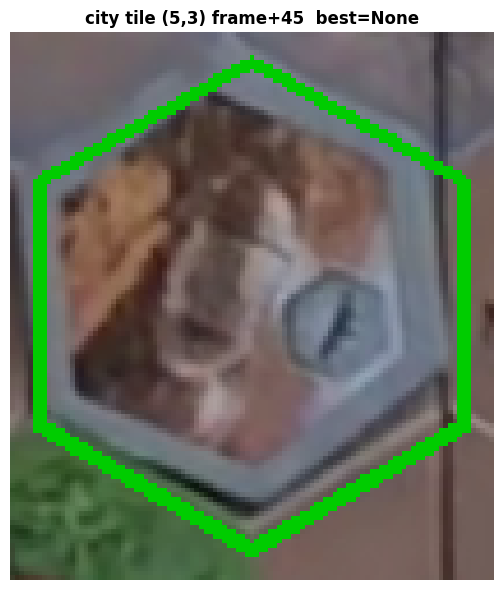

   Frame  50: - No detection
   Frame  60: - No detection


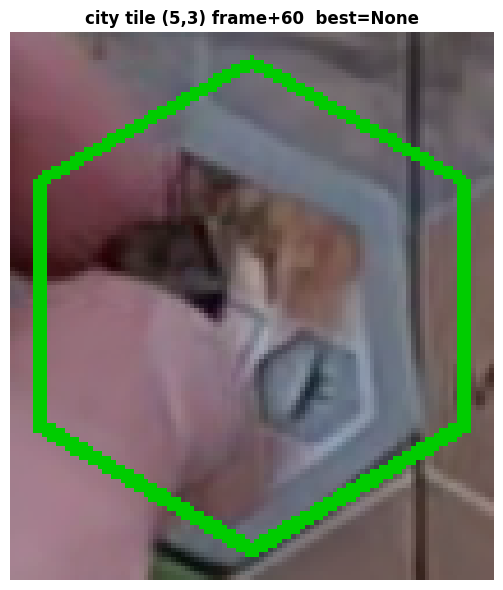

   Frame  89: ✓ BLACK score=  22.9 area= 600 @ (56,54)
   Frame  90: ✓ BLACK score=  22.4 area= 575 @ (54,54)


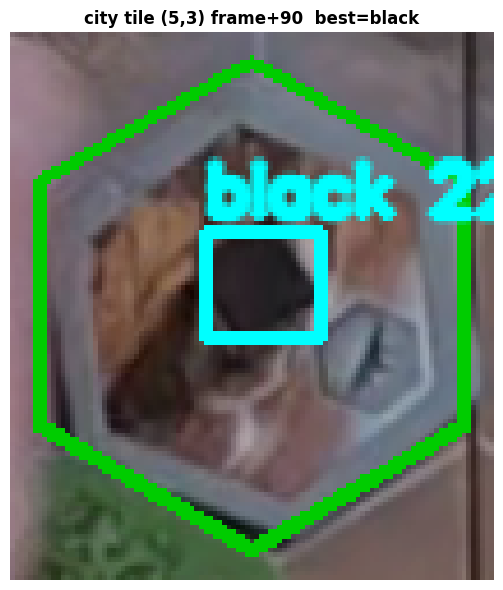

   Frame  91: ✓ BLACK score=  21.0 area= 552 @ (53,56)
   Frame  92: ✓ BLACK score=  25.8 area= 672 @ (52,61)


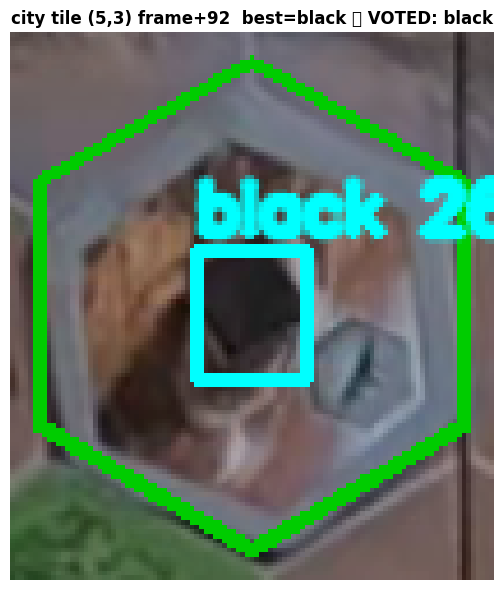


✅ CUBE DETECTED: BLACK
   Tile: city (5,3)
   Time: 21.00s (frame 92/93)
   Detections: 4/93 frames
   BBox: (344, 464, 24, 28)

cube_evt: {'rc': (5, 3), 'color': 'black', 't_sec': 21.00121111111111, 'bbox_map': (344, 464, 24, 28), 'tile_center_map_xy': (356.3065991811442, 475.6791901737299)}

🔍 Searching for cube on FOREST tile (6,4)
   Start delay: 600ms
   Will watch: 359 frames (~12.0s)
   Required hits: 4/8

   Frame   0: - No detection


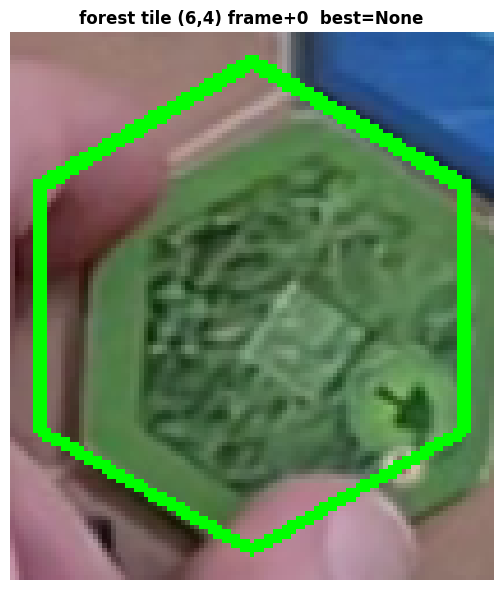

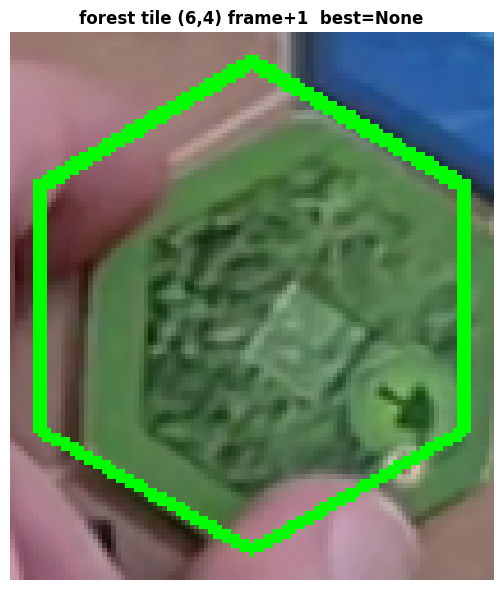

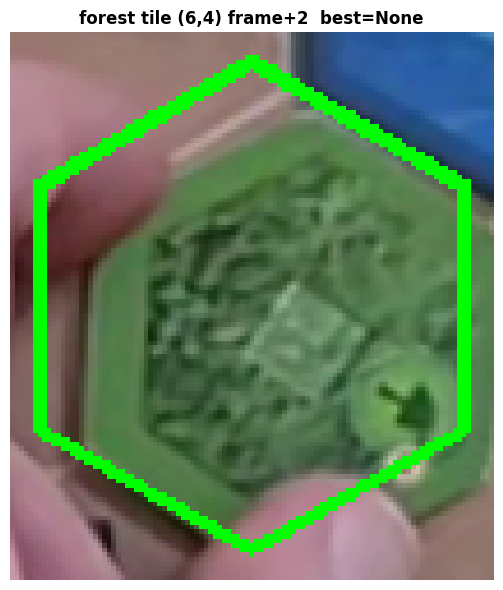

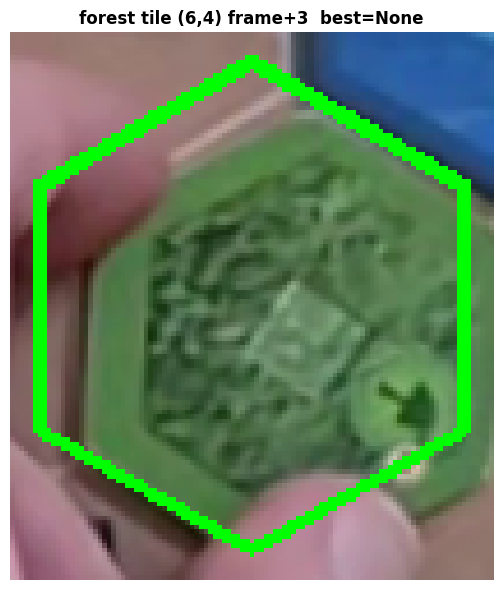

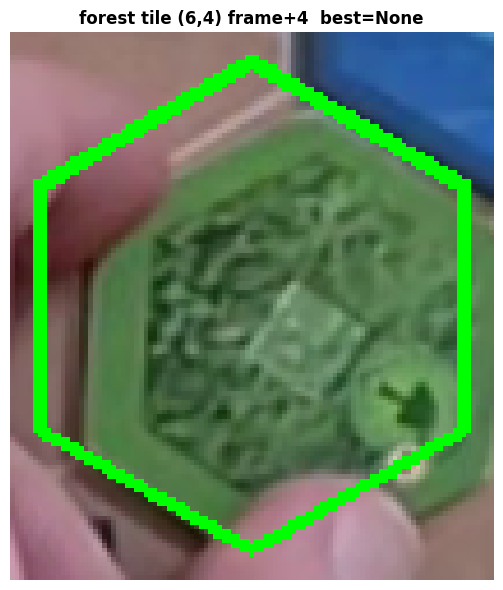

   Frame  10: - No detection


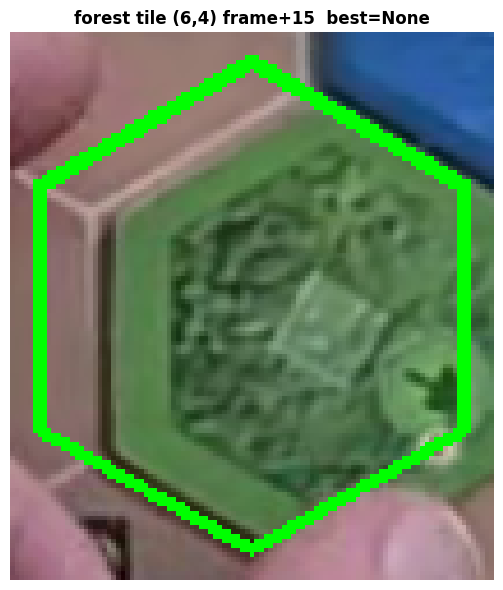

   Frame  20: - No detection
   Frame  30: - No detection


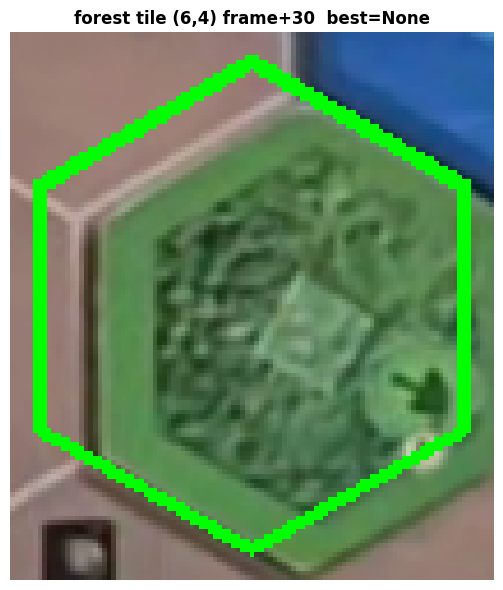

   Frame  40: - No detection


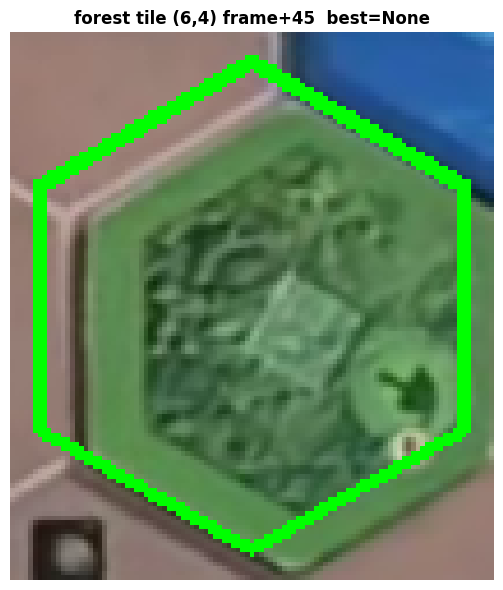

   Frame  50: - No detection
   Frame  60: - No detection


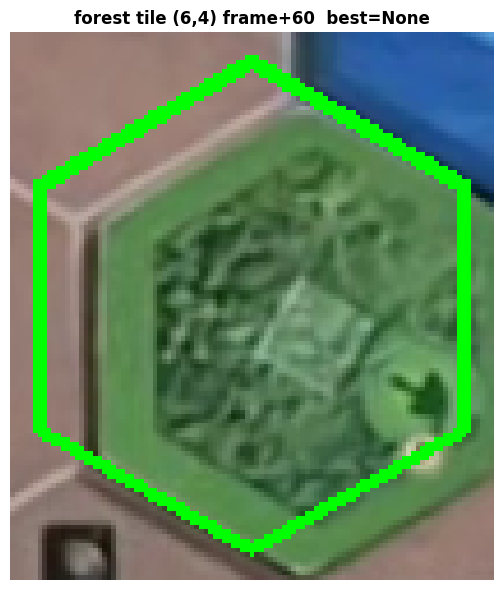

   Frame  70: - No detection


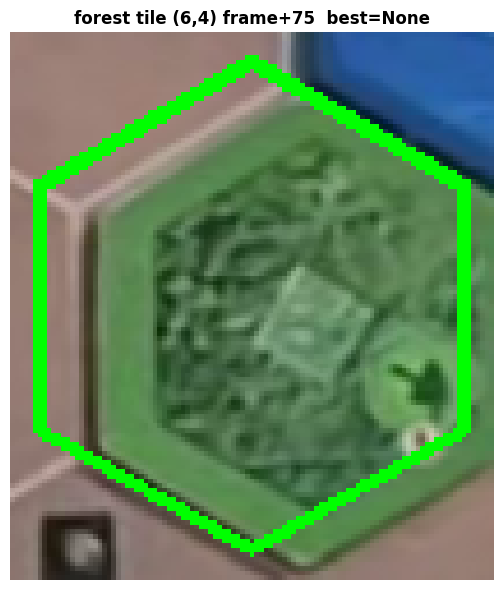

   Frame  80: - No detection
   Frame  90: - No detection


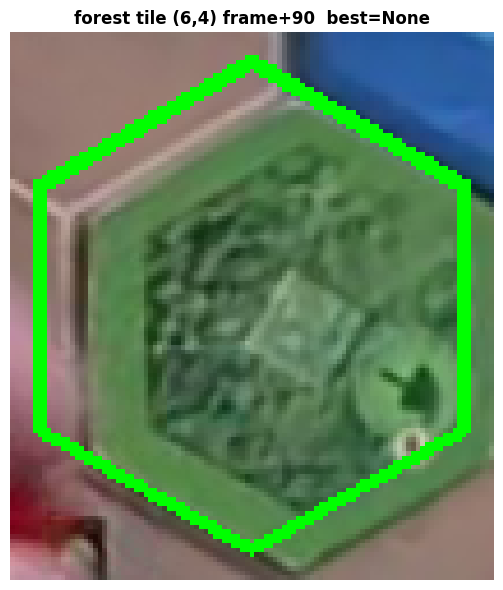

   Frame  97: ✓ RED   score=  23.4 area=1394 @ (46,66)
   Frame 143: ✓ RED   score=  13.9 area= 660 @ (68,69)
   Frame 144: ✓ RED   score=  11.8 area= 638 @ (68,65)
   Frame 146: ✓ RED   score=  28.9 area= 754 @ (66,66)
   Frame 147: ✓ RED   score=  20.7 area= 725 @ (66,66)


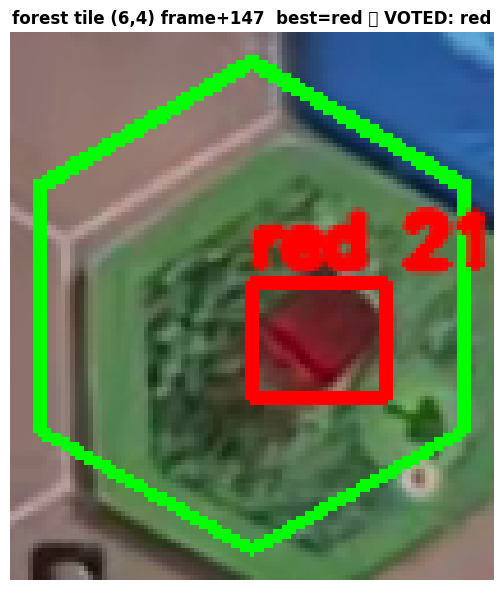


✅ CUBE DETECTED: RED
   Tile: forest (6,4)
   Time: 42.50s (frame 147/148)
   Detections: 5/148 frames
   BBox: (487, 545, 29, 26)

cube_evt: {'rc': (6, 4), 'color': 'red', 't_sec': 42.50244444444445, 'bbox_map': (487, 545, 29, 26), 'tile_center_map_xy': (487.38680163771164, 551.3583803474598)}

🔍 Searching for cube on FOREST tile (1,2)
   Start delay: 600ms
   Will watch: 359 frames (~12.0s)
   Required hits: 4/8

   Frame   0: - No detection


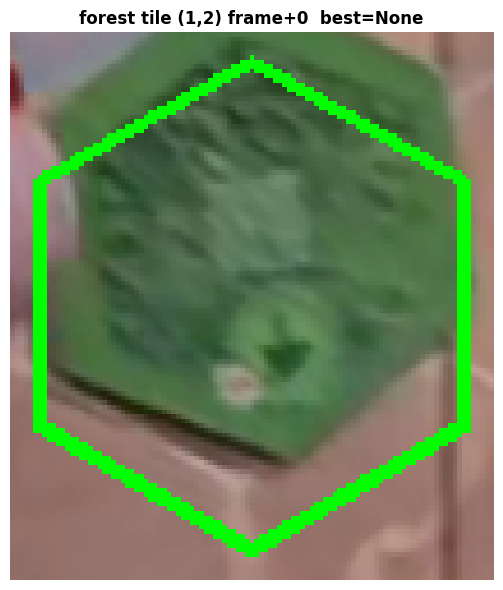

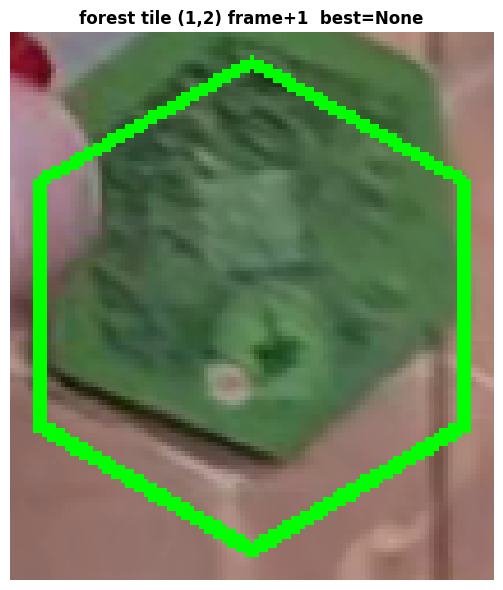

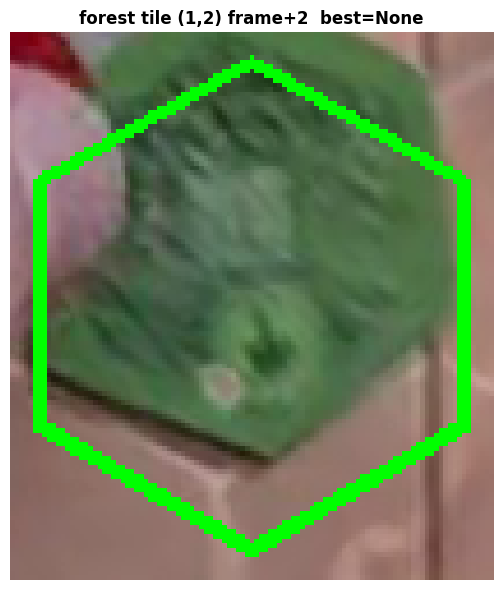

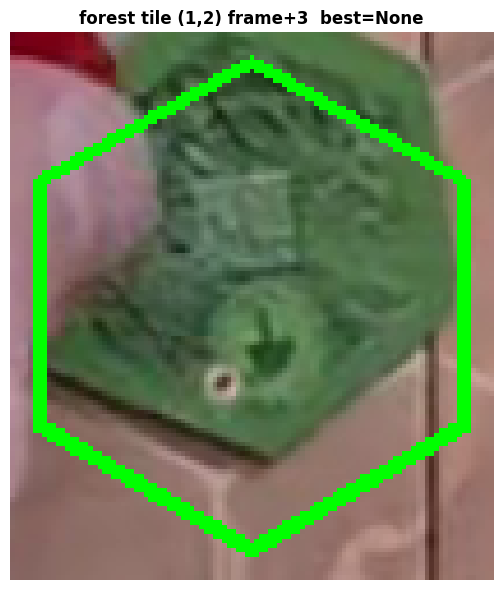

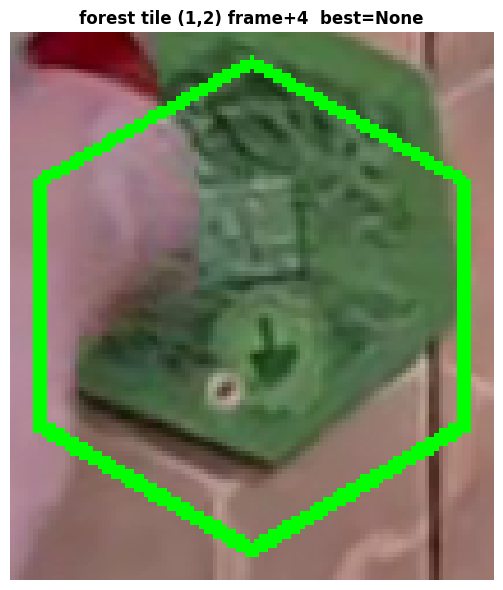

   Frame   7: Occluded
   Frame   8: Occluded
   Frame   9: Occluded
   Frame  10: Occluded
   Frame  11: Occluded
   Frame  12: Occluded
   Frame  13: Occluded
   Frame  14: Occluded
   Frame  15: Occluded
   Frame  16: Occluded
   Frame  17: Occluded
   Frame  18: Occluded
   Frame  19: Occluded
   Frame  20: - No detection
   Frame  21: ✓ RED   score=   5.4 area= 357 @ (64,42)
   Frame  26: ✓ RED   score=   2.4 area= 260 @ (59,40)
   Frame  30: ✓ RED   score=  13.7 area= 616 @ (54,33)


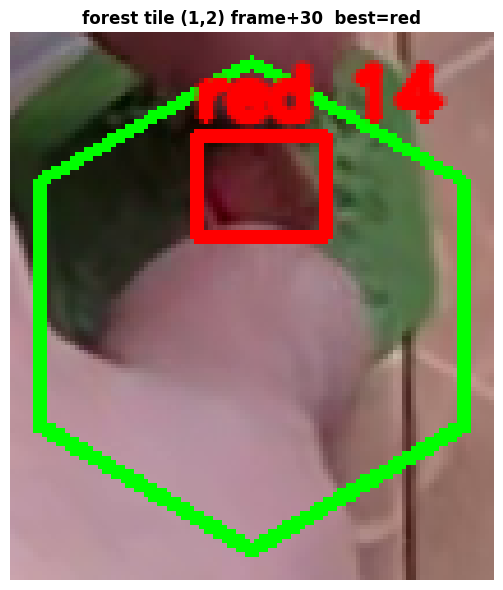

   Frame  40: - No detection
   Frame  45: ✓ RED   score=  25.3 area= 900 @ (55,36)


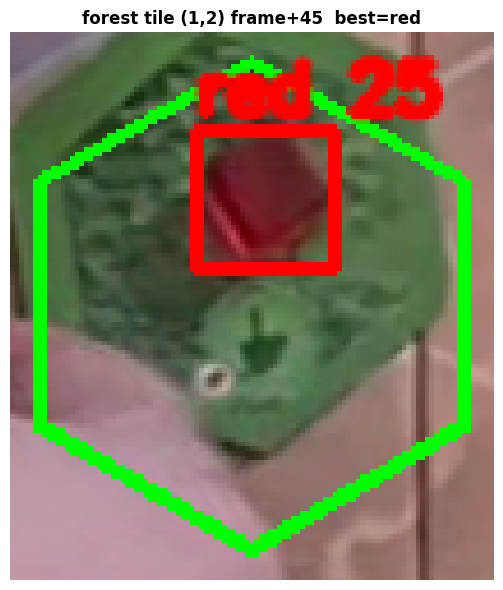

   Frame  53: ✓ RED   score=  28.0 area= 896 @ (56,40)
   Frame  54: ✓ RED   score=  21.0 area= 896 @ (56,39)
   Frame  55: ✓ RED   score=  15.9 area= 924 @ (57,40)
   Frame  56: ✓ RED   score=  20.0 area= 899 @ (58,40)


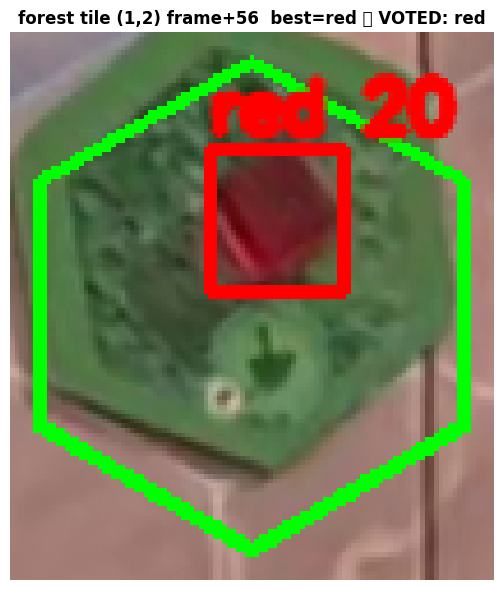


✅ CUBE DETECTED: RED
   Tile: forest (1,2)
   Time: 72.24s (frame 56/57)
   Detections: 8/57 frames
   BBox: (346, 138, 28, 32)

cube_evt: {'rc': (1, 2), 'color': 'red', 't_sec': 72.23748888888889, 'bbox_map': (346, 138, 28, 32), 'tile_center_map_xy': (356.3065991811442, 172.9624294788103)}


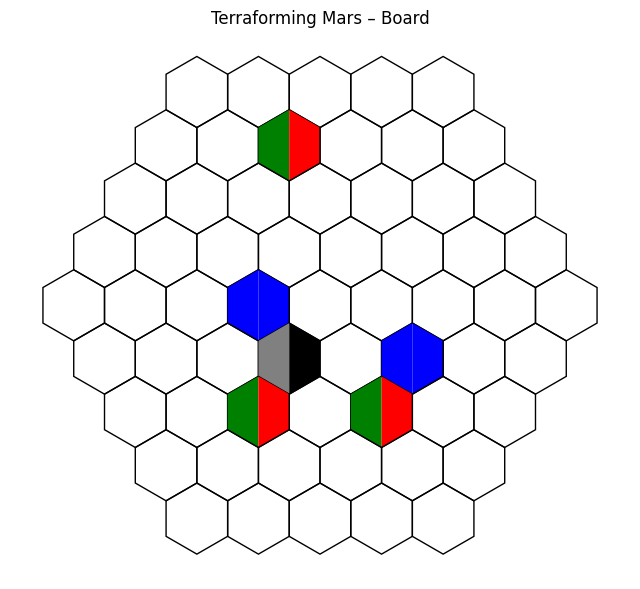

In [44]:
# ==============================
# Tile-focused cube detector (appearance + temporal vote)
# Works in MAP coords (aligned_map 800x800), robust to shake (H smoothing) and finger (occlusion gate)
# Requires your existing:
#   - compute_H_frame_to_map(frame, orb, board_template, map_template, map_size=(800,800))
#   - warp_frame_to_map(frame, H, map_size=(800,800))
#   - Map.centers[(r,c)] in map pixel coords
# ==============================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import deque


def hex_mask_for_tile(H, W, center_xy, hex_radius_px):
    cx, cy = center_xy
    pts = []
    for k in range(6):
        ang = np.deg2rad(60 * k + 30)  # pointy-top
        x = cx + hex_radius_px * np.cos(ang)
        y = cy + hex_radius_px * np.sin(ang)
        pts.append([x, y])
    pts = np.int32(np.round(pts)).reshape(-1, 1, 2)

    m = np.zeros((H, W), np.uint8)
    cv2.fillConvexPoly(m, pts, 255)
    return m, pts


def bbox_from_mask(mask, pad=6):
    ys, xs = np.where(mask > 0)
    if xs.size == 0:
        return None
    x0, x1 = int(xs.min()), int(xs.max())
    y0, y1 = int(ys.min()), int(ys.max())
    x0 = max(0, x0 - pad); y0 = max(0, y0 - pad)
    x1 = min(mask.shape[1] - 1, x1 + pad); y1 = min(mask.shape[0] - 1, y1 + pad)
    return x0, y0, (x1 - x0 + 1), (y1 - y0 + 1)


def occlusion_gate_hex(roi_bgr, roi_hex_mask,
                       max_cov_ratio=0.35,      # STRICTER (was 0.45)
                       bright_v_min=160,        # LOWER (was 170)
                       sat_s_min=40,            # LOWER (was 50)
                       skin_cov_ratio=0.20):
    """
    Fast "finger/hand" rejector:
    - if a large fraction of hex pixels are bright+somewhat saturated, it's likely occluded.
    Tune max_cov_ratio ~0.25-0.45 depending on lighting.
    """
    hsv = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2HSV)
    S = hsv[..., 1].astype(np.uint8)
    V = hsv[..., 2].astype(np.uint8)

    m = (roi_hex_mask > 0)
    if np.count_nonzero(m) < 50:
        return False

    bright = (V >= bright_v_min) & (S >= sat_s_min) & m
    cov = float(np.count_nonzero(bright)) / (float(np.count_nonzero(m)) + 1e-6)

    ycrcb = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2YCrCb)
    Cr = ycrcb[..., 1].astype(np.uint8)
    Cb = ycrcb[..., 2].astype(np.uint8)
    skin = (Cr >= 150) & (Cr <= 175) & (Cb >= 95) & (Cb <= 125) & m
    cov_skin = float(np.count_nonzero(skin)) / (float(np.count_nonzero(m)) + 1e-6)

    skin_u8 = (skin.astype(np.uint8) * 255)
    k3 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
    skin_u8 = cv2.morphologyEx(skin_u8, cv2.MORPH_OPEN, k3, iterations=1)

    touch = False
    b = 4  # border thickness in px
    if np.any(skin_u8[:b, :] > 0) or np.any(skin_u8[-b:, :] > 0) or np.any(skin_u8[:, :b] > 0) or np.any(skin_u8[:, -b:] > 0):
        touch = True


    return (cov > float(max_cov_ratio)) or (cov_skin > float(skin_cov_ratio)) or touch


def find_cube_candidates_in_hex(roi_bgr, roi_hex_mask,
                               min_area=30,
                               max_area=1000,
                               debug=False):
    """
    Returns list of candidates:
      [{"bbox":(x,y,w,h), "centroid":(cx,cy), "kind":"red"/"black", "score":float}, ...]
    ROI coords (not full map coords).
    """
    lab = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2LAB)
    hsv = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2HSV)
    L = lab[..., 0].astype(np.int16)
    A = lab[..., 1].astype(np.int16)
    B = lab[..., 2].astype(np.int16)

    H = hsv[..., 0].astype(np.int16)
    S = hsv[..., 1].astype(np.uint8)
    V = hsv[..., 2].astype(np.uint8)

    m = (roi_hex_mask > 0)
    if np.count_nonzero(m) < 50:
        return []

    # === STRICTER COLOR DETECTION TO AVOID TILE PARTS ===
    
    # RED: Must be VERY red (high A) and not too dark
    red_lab = (A >= 160) & (L >= 60) & (L <= 190) & m  # STRICTER: A>=160, L>=60
    red_hsv = (((H <= 6) | (H >= 172)) & (S >= 110) & (V >= 70) & (V <= 210) & m)  # STRICTER
    red_mask = (red_lab | red_hsv).astype(np.uint8) * 255

    # BLACK: Must be VERY dark AND low saturation (avoid colored tile parts)
    # Key change: stricter L threshold and require low saturation to avoid green/brown tiles
    black_lab = (L <= 65) & (A >= 115) & (A <= 140) & m  # MUCH STRICTER: L<=65 (was 80)
    black_hsv = ((V <= 75) & (S <= 80) & m)  # STRICTER: V<=75 (was 90)
    black_mask = ((L <= 70) & (S <= 70) & (V <= 85) & m).astype(np.uint8) * 255

    # More aggressive cleanup to remove noise
    k3 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    k5 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))  # Back to 5 for more cleanup

    red_u8 = cv2.morphologyEx(red_mask, cv2.MORPH_OPEN, k3, iterations=2)  # 2 iterations
    red_u8 = cv2.morphologyEx(red_u8, cv2.MORPH_CLOSE, k5, iterations=1)

    black_u8 = cv2.morphologyEx(black_mask, cv2.MORPH_OPEN, k3, iterations=2)  # 2 iterations
    black_u8 = cv2.morphologyEx(black_u8, cv2.MORPH_CLOSE, k5, iterations=1)

    candidates = []

    def collect_from_mask(bin_u8, kind):
        cnts, _ = cv2.findContours(bin_u8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for c in cnts:
            area = float(cv2.contourArea(c))
            if area < float(min_area) or area > float(max_area):
                continue

            x, y, w, h = cv2.boundingRect(c)
            
            # STRICTER geometry - cubes should be compact and square-ish
            ar = w / float(h + 1e-6)
            if ar < 0.65 or ar > 1.55:  # Back to stricter (was 0.55-1.75)
                continue
            
            extent = area / float(w * h + 1e-6)
            if extent < 0.35:  # Back to stricter (was 0.30)
                continue
            

            hull = cv2.convexHull(c)
            hull_area = float(cv2.contourArea(hull)) + 1e-6
            solidity = area / hull_area
            if solidity < 0.70:
                continue

            # NEW: Check if blob touches hex border
            # If it doesn't touch borders, it's definitely a valid cube
            x0 = max(0, x); y0 = max(0, y)
            x1 = min(roi_hex_mask.shape[1], x + w)
            y1 = min(roi_hex_mask.shape[0], y + h)
            
            blob_mask = np.zeros_like(roi_hex_mask)
            blob_mask[y0:y1, x0:x1] = 255
            
            # Check if blob touches the edge of the hex mask (border of tile)
            border_thickness = 5  # pixels from edge to consider as "border"
            
            # Create a border-only mask (erode hex to get interior, subtract to get border)
            kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (border_thickness*2, border_thickness*2))
            hex_interior = cv2.erode(roi_hex_mask, kernel, iterations=1)
            hex_border = cv2.subtract(roi_hex_mask, hex_interior)
            
            # Check if blob overlaps with border
            overlap_with_border = cv2.bitwise_and(blob_mask, hex_border)
            touches_border = np.count_nonzero(overlap_with_border) > 0

            if touches_border:
                continue

            # CRITICAL: Check if blob is actually 3D cube-like (not flat tile)
            # Cubes have distinct edges, tiles are more uniform
            x0 = max(0, x); y0 = max(0, y)
            x1 = min(roi_hex_mask.shape[1], x + w)
            y1 = min(roi_hex_mask.shape[0], y + h)
            
            inside = float(np.count_nonzero(roi_hex_mask[y0:y1, x0:x1] > 0))
            box_area = float((x1 - x0) * (y1 - y0) + 1e-6)
            if inside / box_area < 0.75:  # Back to stricter
                continue

            # NEW: Edge density check - cubes have sharp edges, tiles don't
            blob_region = roi_bgr[y0:y1, x0:x1]
            blob_gray = cv2.cvtColor(blob_region, cv2.COLOR_BGR2GRAY)

            # p10 = np.percentile(blob_gray, 10)
            # p90 = np.percentile(blob_gray, 90)
            # if (p90 - p10) < 35:   # tune 30..45
            #     print(f"pct: {p90 - p10}")
            #     continue


            edges = cv2.Canny(blob_gray, 50, 150)
            edge_density = np.count_nonzero(edges) / (blob_gray.size + 1e-6)
            
            # Cubes should have moderate edge density (0.05-0.25)
            # Tile parts have either too few or too many edges
            # if edge_density < 0.05 or edge_density > 0.25:
            #     print(f"Edge density {edge_density}")
            #     continue

            # NEW: Standard deviation check - cubes have variation, flat tiles don't
            std_dev = np.std(blob_gray)
            # if std_dev < 15.0:  # Too uniform = probably flat tile
            #     print(f"std_dev: {std_dev}")
            #     continue

            cx = x + 0.5 * w
            cy = y + 0.5 * h

            # Enhanced score with edge and std factors
            score = area * solidity * extent * edge_density * (std_dev / 50.0)
            candidates.append({
                "bbox": (int(x), int(y), int(w), int(h)),
                "centroid": (float(cx), float(cy)),
                "kind": kind,
                "score": float(score),
                "edge_density": float(edge_density),
                "std_dev": float(std_dev)
            })

    collect_from_mask(red_u8, "red")
    collect_from_mask(black_u8, "black")

    candidates.sort(key=lambda d: d["score"], reverse=True)

    if debug:
        vis = roi_bgr.copy()
        vis = cv2.bitwise_and(vis, vis, mask=roi_hex_mask)
        for i, cand in enumerate(candidates[:5]):
            x, y, w, h = cand["bbox"]
            cv2.rectangle(vis, (x, y), (x + w, y + h), (0, 255, 255), 2)
            cv2.putText(vis, f"{cand['kind']} e:{cand['edge_density']:.2f} s:{cand['std_dev']:.0f}", 
                        (x, y - 3), cv2.FONT_HERSHEY_SIMPLEX, 0.35, (255, 255, 0), 1, cv2.LINE_AA)
        plt.figure(figsize=(10, 3))
        plt.subplot(1, 3, 1); plt.title("roi"); plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)); plt.axis("off")
        plt.subplot(1, 3, 2); plt.title("red_u8"); plt.imshow(red_u8, cmap="gray"); plt.axis("off")
        plt.subplot(1, 3, 3); plt.title("black_u8"); plt.imshow(black_u8, cmap="gray"); plt.axis("off")
        plt.tight_layout(); plt.show()

    return candidates

def vote_cube_over_time(cand_history,
                        required_hits=6,
                        window=12,
                        max_centroid_jitter=15.0):
    """
    cand_history: deque of either None or candidate dicts (best per frame).
    Returns (kind, bbox, centroid) or None
    """
    recent = list(cand_history)[-window:]
    hits = [c for c in recent if c is not None]
    if len(hits) < required_hits:
        return None

    # majority kind vote
    kinds = [c["kind"] for c in hits]
    kind = max(set(kinds), key=kinds.count)

    kind_hits = [c for c in hits if c["kind"] == kind]
    if len(kind_hits) < required_hits:
        return None

    # centroid jitter gate
    cx = np.array([c["centroid"][0] for c in kind_hits], dtype=np.float32)
    cy = np.array([c["centroid"][1] for c in kind_hits], dtype=np.float32)
    if (cx.max() - cx.min()) > max_centroid_jitter or (cy.max() - cy.min()) > max_centroid_jitter:
        return None

    # take best score instance as bbox representative
    best = max(kind_hits, key=lambda c: c["score"])
    return kind, best["bbox"], best["centroid"]

def mask_out_tile_artwork(roi_bgr, roi_hex_mask, tile_type):
    """
    Create detection mask that excludes tile artwork areas
    """
    if tile_type == "ocean":
        return roi_bgr, roi_hex_mask
    
    h, w = roi_bgr.shape[:2]
    cx, cy = w // 2, h // 2
    work_mask = roi_hex_mask.copy()
        
    if tile_type == "city":
        # 1) mask the top city-icon
        icon_y = int(h * 0.22)
        icon_r = int(min(w, h) * 0.22)
        cv2.circle(work_mask, (cx, icon_y), icon_r, 0, -1)

        # 2) mask top band (most false positives live there)
        work_mask[:int(h * 0.30), :] = 0

        # 3) KEEP a big center/bottom zone (center stays unmasked)
        keep = np.zeros_like(work_mask)
        cv2.ellipse(
            keep,
            (cx, int(h * 0.60)),                 # lower than your 0.48 so it covers the cube
            (int(w * 0.32), int(h * 0.26)),      # bigger so it doesn't clip cube
            0, 0, 360, 255, -1
        )
        work_mask = cv2.bitwise_and(work_mask, keep)

        # 4) remove left/right “building shadow” lanes (but keep center)
        y_lane0 = int(h * 0.40)
        x_lane  = int(w * 0.22)
        work_mask[y_lane0:, :x_lane] = 0
        work_mask[y_lane0:, w - x_lane:] = 0




    elif tile_type == "forest":
        center_r = int(min(w, h) * 0.20)
        cv2.circle(work_mask, (cx, cy), center_r, 0, -1)
    
    return roi_bgr, work_mask


def find_cube_on_tile_after_event(
    video_path,
    event,
    orb,
    dataset,
    r, c,
    tile_center_map_xy,
    map_size=(800, 800),
    crop_r=34,
    start_delay_ms=600,
    watch_seconds=12.0,
    H_smooth_alpha=0.25,
    required_hits=6,
    vote_window=12,  # CHANGED from 8
    min_area=30,     # CHANGED from 35
    debug=False
):
    """
    Tile-focused cube detection with detailed debugging
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError("Could not open video")

    # Seek
    if "time_sec" in event:
        cap.set(cv2.CAP_PROP_POS_MSEC, int(event["time_sec"] * 1000 + start_delay_ms))
    else:
        fps0 = cap.get(cv2.CAP_PROP_FPS) or 30.0
        cap.set(cv2.CAP_PROP_POS_FRAMES, max(0, int(event["frame_idx"] + (start_delay_ms / 1000.0) * fps0)))

    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    max_frames = int(watch_seconds * fps)

    cx_map, cy_map = float(tile_center_map_xy[0]), float(tile_center_map_xy[1])
    tile_type = event["tile"]
    
    print(f"\n{'='*60}")
    print(f"🔍 Searching for cube on {tile_type.upper()} tile ({r},{c})")
    print(f"   Start delay: {start_delay_ms}ms")
    print(f"   Will watch: {max_frames} frames (~{watch_seconds:.1f}s)")
    print(f"   Required hits: {required_hits}/{vote_window}")
    print(f"{'='*60}\n")

    hex_radius_px = int(round(crop_r * 1.55))
    full_hex_mask, full_hex_pts = hex_mask_for_tile(
        H=map_size[1], W=map_size[0],
        center_xy=(cx_map, cy_map),
        hex_radius_px=hex_radius_px
    )
    bb = bbox_from_mask(full_hex_mask, pad=6)
    if bb is None:
        cap.release()
        return None
    x0, y0, w0, h0 = bb

    roi_hex_mask = full_hex_mask[y0:y0+h0, x0:x0+w0].copy()
    roi_hex_pts = full_hex_pts.copy()
    roi_hex_pts[:, 0, 0] -= x0
    roi_hex_pts[:, 0, 1] -= y0

    H_prev = None
    cand_hist = deque(maxlen=max(vote_window, required_hits) + 2)
    
    frames_with_detection = 0
    frames_processed = 0

    for i in range(max_frames):
        ok, frame = cap.read()
        if not ok:
            break
        
        frames_processed += 1

        H_f2m = compute_H_frame_to_map(
            frame,
            orb,
            dataset["board"]["board"],
            dataset["regions"]["map"],
            map_size=map_size
        )
        if H_f2m is None:
            H_prev = None
            cand_hist.append(None)
            if debug and i < 20:
                print(f"   Frame {i:3d}: No homography")
            continue

        H = H_f2m / (H_f2m[2, 2] + 1e-9)
        if H_prev is None:
            H_prev = H
        else:
            H_prev = (1.0 - H_smooth_alpha) * H_prev + H_smooth_alpha * H
            H_prev = H_prev / (H_prev[2, 2] + 1e-9)

        aligned_map = warp_frame_to_map(frame, H_prev, map_size=map_size)
        roi = aligned_map[y0:y0+h0, x0:x0+w0].copy()
        
        # Mask out tile artwork
        #roi_processed, mask_processed = mask_out_tile_artwork(roi, roi_hex_mask, tile_type)
        roi_processed, mask_processed = roi, roi_hex_mask

        
        # Check occlusion
        if occlusion_gate_hex(roi, roi_hex_mask):  # Check on ORIGINAL roi
            cand_hist.append(None)
            if debug and i < 20:
                print(f"   Frame {i:3d}: Occluded")
            continue

        # Find candidates
        candidates = find_cube_candidates_in_hex(
            roi_processed, mask_processed,
            min_area=min_area,
            max_area=1000,
            debug=False
        )
        
        best = candidates[0] if candidates else None
        cand_hist.append(best)
        
        if best is not None:
            frames_with_detection += 1
        
        # Print every detection or every 10 frames
        if debug and (best is not None or i % 10 == 0):
            if best is not None:
                print(f"   Frame {i:3d}: ✓ {best['kind'].upper():5s} score={best['score']:6.1f} area={best['bbox'][2]*best['bbox'][3]:4.0f} @ ({best['centroid'][0]:.0f},{best['centroid'][1]:.0f})")
            elif i % 10 == 0:
                print(f"   Frame {i:3d}: - No detection")

        # Check voting
        voted = vote_cube_over_time(
            cand_hist,
            required_hits=required_hits,
            window=vote_window,
            max_centroid_jitter=15.0
        )

        # Enhanced visualization
        if debug and (i < 5 or i % 15 == 0 or voted is not None):
            vis = roi.copy()  # Show ORIGINAL, not processed
            cv2.polylines(vis, [roi_hex_pts], True, (0, 255, 0), 2)
            
            # Draw mask visualization
            if tile_type == "city":
                h_roi, w_roi = roi.shape[:2]
                cx_roi, cy_roi = w_roi // 2, h_roi // 2
                
                # Show masked areas in semi-transparent
                mask_vis = np.zeros_like(vis)
                mask_diff = cv2.bitwise_xor(roi_hex_mask, mask_processed)
                mask_vis[mask_diff > 0] = [255, 0, 255]  # Magenta for masked areas
                vis = cv2.addWeighted(vis, 0.8, mask_vis, 0.2, 0)
            
            if best is not None:
                x, y, w, h = best["bbox"]
                color = (0, 0, 255) if best["kind"] == "red" else (255, 255, 0)
                cv2.rectangle(vis, (x, y), (x + w, y + h), color, 2)
                cv2.putText(vis, f"{best['kind']} {best['score']:.0f}", (x, y - 4),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2, cv2.LINE_AA)
            
            title = f"{tile_type} tile ({r},{c}) frame+{i}  best={best['kind'] if best else 'None'}"
            if voted is not None:
                title += f" ✅ VOTED: {voted[0]}"
            
            plt.figure(figsize=(8, 6))
            plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
            plt.title(title, fontsize=12, fontweight='bold')
            plt.axis("off")
            plt.tight_layout()
            plt.show()

        if voted is not None:
            kind, bbox_roi, centroid_roi = voted

            bx, by, bw, bh = bbox_roi
            bbox_map = (int(bx + x0), int(by + y0), int(bw), int(bh))

            t_sec = cap.get(cv2.CAP_PROP_POS_MSEC) / 1000.0
            
            print(f"\n{'='*60}")
            print(f"✅ CUBE DETECTED: {kind.upper()}")
            print(f"   Tile: {tile_type} ({r},{c})")
            print(f"   Time: {t_sec:.2f}s (frame {i}/{frames_processed})")
            print(f"   Detections: {frames_with_detection}/{frames_processed} frames")
            print(f"   BBox: {bbox_map}")
            print(f"{'='*60}\n")
            
            cap.release()
            return {
                "rc": (r, c),
                "color": kind,
                "t_sec": float(t_sec),
                "bbox_map": bbox_map,
                "tile_center_map_xy": (cx_map, cy_map)
            }

    cap.release()
    
    print(f"\n{'='*60}")
    print(f"❌ NO CUBE DETECTED")
    print(f"   Tile: {tile_type} ({r},{c})")
    print(f"   Frames processed: {frames_processed}/{max_frames}")
    print(f"   Frames with detection: {frames_with_detection}")
    print(f"   Detection rate: {100*frames_with_detection/(frames_processed+1e-6):.1f}%")
    print(f"{'='*60}\n")
    
    return None


# ==============================
# Testing / usage
# ==============================


# Assumes you already have:
#   - events: list of tile placement events with "tile", "time_sec" or "frame_idx", and "pos_map_xy"/(r,c)
#   - map_model with centers[(r,c)] in map pixels
#   - orb, dataset loaded (board/map templates)
#
# Example integration:
def test_cubes_for_events(events, map_model, orb, dataset, debug_one=False):
    out = []
    for idx, e in enumerate(events):
        tile_type = e["tile"]
        if tile_type == "ocean":
            continue

        # you already do this earlier: r,c from nearest_hex of the placement point
        r, c = e["rc"] if "rc" in e else map_model.nearest_hex(*e["pos_map_xy"])
        center = map_model.centers[(r, c)]

        evt = find_cube_on_tile_after_event(
            VIDEO_PATH,
            event=e,
            orb=orb,
            dataset=dataset,
            r=r, c=c,
            tile_center_map_xy=center,
            start_delay_ms=600,
            watch_seconds=12.0,
            crop_r=34,
            required_hits=4,
            vote_window=8,
            min_area=125,
            debug=True
        )
        print("cube_evt:", evt)
        out.append(evt)
    return out


cube_events = test_cubes_for_events(events, map_model, orb, dataset, debug_one=True)
for ce in cube_events:
    if ce is None: continue
    r,c = ce["rc"]
    map_model.set_owner(r, c, ce["color"])
map_model.draw()


In [52]:
import cv2
import numpy as np
from collections import deque


# -----------------------------
# SETTINGS (template-coords!)
# -----------------------------
BOARD_SIZE = (1200, 1200)

# IMPORTANT: these y values must be in the STABILIZED thermo_patch coordinates
CALIB = {
    "y_top_tick_frac": 45.0 / 770.0,      # was 45
    "y_bottom_tick_frac": 0.93,  # was 770  (== 1.0)
    "t_min": -30,
    "t_max": 8,
    "step": 2,
}


# anchor inside cube bbox to read temperature:
# 0.0 = top edge, 0.5 = center. Usually 0.15–0.30 works best.
Y_ANCHOR_FRAC = 1

VOTE_WINDOW = 14
VOTE_NEED   = 9


# -----------------------------
# STABILIZE THERMO PATCH
# -----------------------------
def warp_frame_to_board(frame_bgr, H_frame_to_board, board_size):
    BW, BH = board_size
    return cv2.warpPerspective(frame_bgr, H_frame_to_board, (BW, BH))


def warp_board_to_temp_template(board_topdown_bgr, temp_template, H):
    """
    temp_template.img is grayscale template (th,tw)
    H_temp_to_board maps template -> board_topdown
    Returns thermo_patch in TEMPLATE coords => stabilized.
    """
    th, tw = temp_template.img.shape[:2]
    # CHANGED in warp_board_to_temp_template: safe inverse + guard
    if H is None or (not np.isfinite(H).all()):
        return None

    ok, H_board_to_temp = cv2.invert(H, flags=cv2.DECOMP_SVD)  # ok==0 => not invertible
    if ok == 0:
        return None

    patch = cv2.warpPerspective(board_topdown_bgr, H_board_to_temp, (tw, th))
    return patch


# -----------------------------
# WHITE CUBE DETECTOR (bbox)
# -----------------------------
def detect_white_temp_cube_bbox(thermo_patch_bgr, debug=False):
    """
    Returns: (bbox_xywh, center_xy, vis, dbg)
    """
    h, w = thermo_patch_bgr.shape[:2]
    
    # CREATE TUBE MASK - only look in center vertical strip
    tube_mask = np.zeros((h, w), dtype=np.uint8)
    tube_x_start = int(w * 0.25)  # adjust these based on your tube position
    tube_x_end = int(w * 0.75)
    tube_mask[:, tube_x_start:tube_x_end] = 255
    
    hsv = cv2.cvtColor(thermo_patch_bgr, cv2.COLOR_BGR2HSV)
    S = hsv[..., 1]
    V = hsv[..., 2]

    white = ((S < 85) & (V > 150)).astype(np.uint8) * 255
    
    # APPLY TUBE MASK BEFORE morphology
    white = cv2.bitwise_and(white, white, mask=tube_mask)

    k9 = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9))
    k7 = cv2.getStructuringElement(cv2.MORPH_RECT, (7, 7))
    white_open = cv2.morphologyEx(white, cv2.MORPH_OPEN, k9, iterations=1)
    white_open = cv2.morphologyEx(white_open, cv2.MORPH_CLOSE, k7, iterations=1)
    

    n, labels, stats, centroids = cv2.connectedComponentsWithStats(white_open, connectivity=8)

    best = None
    best_score = -1e18

    for i in range(1, n):
        x, y, ww, hh, area = stats[i]
        if area < 120 or area > 6000:
            continue

        ar = ww / float(hh + 1e-6)
        if ar < 0.65 or ar > 1.55:
            continue

        mask_i = (labels == i).astype(np.uint8) * 255
        cnts, _ = cv2.findContours(mask_i, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not cnts:
            continue
        c = max(cnts, key=cv2.contourArea)
        area_c = float(cv2.contourArea(c))
        if area_c < 120:
            continue

        peri = float(cv2.arcLength(c, True))
        compact = 4.0 * np.pi * area_c / (peri * peri + 1e-6)  # 0..1

        extent = area_c / float(ww * hh + 1e-6)               # filled bbox ratio
        square_pen = abs(ar - 1.0)

        # emphasize "filled square blob"
        score = (3.0 * extent) + (2.0 * compact) + (0.0005 * area_c) - (1.5 * square_pen)

        if score > best_score:
            best_score = score
            best = (int(x), int(y), int(ww), int(hh), float(centroids[i][0]), float(centroids[i][1]))

    dbg = {"white": white, "white_open": white_open}

    if best is None:
        return None, None, (thermo_patch_bgr.copy() if debug else None), (dbg if debug else {})

    x, y, ww, hh, cx, cy = best
    bbox = (x, y, ww, hh)
    center = (cx, cy)

    if not debug:
        return bbox, center, None, {}

    vis = thermo_patch_bgr.copy()
    cv2.rectangle(vis, (x, y), (x + ww, y + hh), (0, 255, 0), 2)
    cv2.circle(vis, (int(cx), int(cy)), 4, (0, 0, 255), -1)
    cv2.putText(vis, "CUBE", (x, max(0, y - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
    return bbox, center, vis, dbg


# -----------------------------
# BBOX -> TEMPERATURE
# -----------------------------
def temp_from_cube_bbox(bbox_xywh, calib, y_anchor_frac=0.20):
    if bbox_xywh is None:
        return None, None

    x, y, w, h = bbox_xywh
    y_ref = float(y) + float(h) * float(y_anchor_frac)  # use near TOP of cube

    H = float(calib["_patch_h"])  # injected per-frame
    y0 = H * float(calib["y_top_tick_frac"])
    y1 = H * float(calib["y_bottom_tick_frac"])

    if abs(y1 - y0) < 1e-6:
        return None, None

    y_ref = float(np.clip(y_ref, min(y0, y1), max(y0, y1)))

    t_min = float(calib["t_min"])
    t_max = float(calib["t_max"])
    step  = float(calib["step"])

    t = t_min + (y1 - y_ref) * (t_max - t_min) / (y1 - y0)
    t = float(np.clip(t, t_min, t_max))
    t = step * round(t / step)

    return int(t), y_ref


# -----------------------------
# STABILIZER
# -----------------------------
class TempVoter:
    def __init__(self, window=14, need=9):
        self.buf = deque(maxlen=int(window))
        self.need = int(need)

    def push(self, val):
        if val is not None:
            self.buf.append(int(val))
        if not self.buf:
            return None
        vals, counts = np.unique(np.array(self.buf), return_counts=True)
        best = int(vals[np.argmax(counts)])
        return best if int(counts.max()) >= self.need else None


# -----------------------------
# SINGLE DEBUG WINDOW (stacked)
# ----------------------------



# -----------------------------
# TEST RUNNER
# -----------------------------
def test_thermometer_temp_boardspace(
    video_path,
    orb,
    dataset,
    start_frame=0,
    max_frames=2500,
    refresh_every=10,
    debug=True,
):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError("Could not open video")

    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(start_frame))

    voter = TempVoter(window=VOTE_WINDOW, need=VOTE_NEED)
    H_frame_to_board = None
    frame_idx = int(start_frame)

    if debug:
        cv2.namedWindow("THERMO DEBUG", cv2.WINDOW_NORMAL)

    temp_tpl = dataset["regions"]["temperature"]

    while True:
        ok, frame = cap.read()
        if not ok:
            break
        frame_idx += 1
        if max_frames is not None and frame_idx > int(start_frame + max_frames):
            break

        # refresh frame->board homography
        if H_frame_to_board is None or (frame_idx % int(refresh_every) == 0):
            H_new = find_homography_frame_to_board(
                frame_bgr=frame,
                board_template=dataset["board"]["board"],
                orb=orb,
                board_size=BOARD_SIZE,
            )
            if H_new is not None:
                H_frame_to_board = H_new
        if H_frame_to_board is None:
            continue

        board_topdown = warp_frame_to_board(frame, H_frame_to_board, BOARD_SIZE)

        # detect temperature template on board_topdown (ORB)
        res = detect_template(board_topdown, temp_tpl, orb, ratio=0.75, min_good=12, ransac_thresh=4.0)
        if res is None or int(res.get("inliers", 0)) < 10:
            continue

        # stabilized thermo patch (template coords)
        thermo_patch = warp_board_to_temp_template(board_topdown, temp_tpl, res["H"])

        bbox, center, overlay, dbg = detect_white_temp_cube_bbox(thermo_patch, debug=True)

        CALIB["_patch_h"] = thermo_patch.shape[0]
        t_inst, y_ref = temp_from_cube_bbox(bbox, CALIB, y_anchor_frac=Y_ANCHOR_FRAC)

        t_inst, y_ref = temp_from_cube_bbox(bbox, CALIB, y_anchor_frac=Y_ANCHOR_FRAC)

        # draw y_ref line on overlay (so you SEE what y is used)
        if overlay is not None and y_ref is not None:
            cv2.line(overlay, (0, int(y_ref)), (overlay.shape[1]-1, int(y_ref)), (255, 0, 255), 2)

        # also draw calib lines (so you can verify y_top/y_bottom are correct)
        if overlay is not None:
            y_top = int(thermo_patch.shape[0] * CALIB["y_top_tick_frac"])
            y_bot = int(thermo_patch.shape[0] * CALIB["y_bottom_tick_frac"])
            cv2.line(overlay, (0, y_top), (overlay.shape[1]-1, y_top), (0,255,255), 1)
            cv2.line(overlay, (0, y_bot), (overlay.shape[1]-1, y_bot), (0,255,255), 1)

        t_stable = voter.push(t_inst)

        if t_stable is not None:
            t_sec = frame_idx / float(fps)
            print(f"TEMP stable = {t_stable}C @ t={t_sec:.2f}s (frame={frame_idx})")

        if debug:

            show_debug_grid(
                "THERMO DEBUG",
                imgs=[thermo_patch, dbg.get("white"), dbg.get("white_open"), overlay],
                labels=["PATCH", "TUBE", "WHITE_IN_TUBE", "RESULT"],
                cell_size=(260, 520)
            )

            k = cv2.waitKey(1) & 0xFF
            if k == ord("q"):
                break

    cap.release()
    if debug:
        cv2.destroyWindow("THERMO DEBUG")


In [53]:
cv2.destroyAllWindows()
test_thermometer_temp_boardspace(
    VIDEO_PATH,
    orb=orb,
    dataset=dataset,
    start_frame=0,
    max_frames=25000,
    refresh_every=10,
    debug=True,
)
cv2.destroyAllWindows()


TEMP stable = -30C @ t=11.50s (frame=345)
TEMP stable = -30C @ t=11.53s (frame=346)
TEMP stable = -30C @ t=11.57s (frame=347)
TEMP stable = -30C @ t=11.60s (frame=348)
TEMP stable = -30C @ t=11.63s (frame=349)
TEMP stable = -30C @ t=11.67s (frame=350)
TEMP stable = -30C @ t=11.70s (frame=351)
TEMP stable = -30C @ t=11.73s (frame=352)
TEMP stable = -30C @ t=11.77s (frame=353)
TEMP stable = -30C @ t=11.80s (frame=354)
TEMP stable = -30C @ t=11.83s (frame=355)
TEMP stable = -30C @ t=11.87s (frame=356)
TEMP stable = -30C @ t=11.90s (frame=357)
TEMP stable = -30C @ t=11.93s (frame=358)
TEMP stable = -30C @ t=11.97s (frame=359)
TEMP stable = -30C @ t=12.00s (frame=360)
TEMP stable = -30C @ t=12.03s (frame=361)
TEMP stable = -30C @ t=12.07s (frame=362)
TEMP stable = -30C @ t=12.10s (frame=363)
TEMP stable = -30C @ t=12.13s (frame=364)
TEMP stable = -30C @ t=12.17s (frame=365)
TEMP stable = -30C @ t=12.20s (frame=366)
TEMP stable = -30C @ t=12.23s (frame=367)
TEMP stable = -30C @ t=12.27s (fra

KeyboardInterrupt: 

In [54]:
CALIB_TEMP = {
    "y_top_tick_frac": 45.0 / 770.0,
    "y_bottom_tick_frac": 0.93,

    "v_min": -30,
    "v_max": 8,
    "step": 2,
}

def value_from_cube_arc(bbox_xywh, calib, anchor_xy_frac=(0.5, 0.75)):
    if bbox_xywh is None:
        return None, None, None  # (value, angle_deg, pt_xy)

    x, y, w, h = bbox_xywh
    axf, ayf = anchor_xy_frac
    px = float(x) + float(w) * float(axf)
    py = float(y) + float(h) * float(ayf)

    cx, cy = calib.get("_center_px", calib["center_xy"])
    dx = px - float(cx)
    dy = py - float(cy)

    # 0..360 degrees (wrap-safe)
    ang = float((np.degrees(np.arctan2(dy, dx)) + 360.0) % 360.0)
    a0 = float(calib["a_min_deg"]) % 360.0
    a1 = float(calib["a_max_deg"]) % 360.0

    # CCW span and CW span
# CCW span and CW span
    span_ccw = (a1 - a0) % 360.0
    span_cw  = (a0 - a1) % 360.0

    d_ccw = (ang - a0) % 360.0   # how far from a0 to ang going CCW
    d_cw  = (a0 - ang) % 360.0   # how far from a0 to ang going CW

    # Pick the direction where 'ang' lies within the span (i.e. doesn't overshoot end)
    ok_ccw = (d_ccw <= span_ccw + 1e-6)
    ok_cw  = (d_cw  <= span_cw  + 1e-6)

    if ok_ccw and not ok_cw:
        span, d = span_ccw, d_ccw
    elif ok_cw and not ok_ccw:
        span, d = span_cw, d_cw
    else:
        # fallback: choose the smaller normalized progress (closer to start)
        prog_ccw = d_ccw / (span_ccw + 1e-9)
        prog_cw  = d_cw  / (span_cw  + 1e-9)
        if prog_ccw <= prog_cw:
            span, d = span_ccw, d_ccw
        else:
            span, d = span_cw, d_cw


    # clamp along chosen direction
    d_c = min(max(d, 0.0), span)

    v_min = float(calib["v_min"])
    v_max = float(calib["v_max"])
    step  = float(calib["step"])

    v = v_min + (d_c / (span + 1e-9)) * (v_max - v_min)
    v = float(np.clip(v, v_min, v_max))
    v = step * round(v / step)

    return int(v), ang, (px, py)

def build_oxygen_track_mask_from_template(tpl_img, band_px=18, shrink_px=10):
    """
    Returns a mask that keeps ONLY the inner track where the marker sits,
    excluding most digits/outer rim.
    """
    if tpl_img.ndim == 3:
        g = cv2.cvtColor(tpl_img, cv2.COLOR_BGR2GRAY)
    else:
        g = tpl_img

    e = cv2.Canny(g, 40, 120)

    # wide band around arc (your current idea)
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2*band_px+1, 2*band_px+1))
    band = cv2.dilate(e, k, iterations=1)

    # NEW: shrink inward to drop digits/outer rim strokes
    ke = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2*shrink_px+1, 2*shrink_px+1))
    track = cv2.erode(band, ke, iterations=1)

    # keep it clean
    k3 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
    track = cv2.morphologyEx(track, cv2.MORPH_CLOSE, k3, iterations=1)

    return track




def detect_white_oxygen_hexagon_bbox(oxygen_patch_bgr, arc_band_mask, debug=False):
    """
    Detect white hexagon indicator on oxygen arc (in STABILIZED template coords).
    Inputs:
      oxygen_patch_bgr: BGR patch (template coords)
      arc_band_mask: uint8 mask (0/255) selecting only the curved arc band (same HxW)
    Returns:
      (bbox_xywh, center_xy, vis, dbg)
        bbox_xywh: (x,y,w,h) or None
        center_xy: (cx,cy) or None
        vis: overlay image if debug else None
        dbg: {"arc_mask","white","white_open"} if debug else {}
    """
    h, w = oxygen_patch_bgr.shape[:2]

    # --- sanitize arc_band_mask (size + dtype + channels) ---
    if arc_band_mask is None:
        arc_band_mask = np.ones((h, w), dtype=np.uint8) * 255
    else:
        if arc_band_mask.ndim == 3:
            arc_band_mask = arc_band_mask[..., 0]
        if arc_band_mask.shape[:2] != (h, w):
            arc_band_mask = cv2.resize(arc_band_mask, (w, h), interpolation=cv2.INTER_NEAREST)
        arc_band_mask = arc_band_mask.astype(np.uint8)
        if arc_band_mask.max() <= 1:
            arc_band_mask = arc_band_mask * 255

    # --- white threshold ---
    hsv = cv2.cvtColor(oxygen_patch_bgr, cv2.COLOR_BGR2HSV)
    S = hsv[..., 1]
    V = hsv[..., 2]
    white = ((S < 85) & (V > 150)).astype(np.uint8) * 255

    # --- isolate to arc band ---
    white = cv2.bitwise_and(white, white, mask=arc_band_mask)

    dt0 = cv2.distanceTransform((white > 0).astype(np.uint8), cv2.DIST_L2, 5)
    white[dt0 < 2.2] = 0     # tune 1.6..2.4 depending on scale

    # --- morphology (small, so marker survives) ---
    # CHANGED: open a bit, then close a bit less (prevents merging digit strokes)
    k3 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    white_open = cv2.morphologyEx(white, cv2.MORPH_OPEN, k3, iterations=2)


    dt = cv2.distanceTransform((white_open > 0).astype(np.uint8), cv2.DIST_L2, 5)

    # --- connected components ---
    n, labels, stats, centroids = cv2.connectedComponentsWithStats(white_open, connectivity=8)

    areas = stats[1:, cv2.CC_STAT_AREA]  # skip background
    if areas.size > 0:
        K = 3  # keep 3 largest blobs
        keep_ids = (1 + np.argsort(areas)[::-1][:K]).tolist()

        filt = np.zeros_like(white_open)
        for cid in keep_ids:
            filt[labels == cid] = 255
        white_open = filt

        # re-run CC on filtered map so your loop sees only candidates
        n, labels, stats, centroids = cv2.connectedComponentsWithStats(white_open, connectivity=8)


    best = None
    best_score = -1e18

    for i in range(1, n):
        x, y, ww, hh, area = stats[i]

        # start lenient; tighten after you see it lock on
        if area < 40 or area > 2500:
            continue

        ar = ww / float(hh + 1e-6)
        if ar < 0.55 or ar > 1.9:
            continue

        # contour-based shape score (optional but helps)
        mask_i = (labels == i).astype(np.uint8)  # 0/1
        area = stats[i][cv2.CC_STAT_AREA]

        # NEW: reject thin strokes by requiring a decent "thickness"
        dt_max = float(dt[mask_i > 0].max()) if area > 0 else 0.0
        if dt_max < 2.2:        # tune 2.0..3.5 depending on patch scale
            continue

        # NEW: solidity-ish measure (filled vs outline)
        x, y, ww, hh, _ = stats[i]
        extent = area / float(ww * hh + 1e-6)
        if extent < 0.25:       # strokes have low extent
            continue

        # CHANGED scoring: prioritize thick + compact-ish
        score = (6.0 * dt_max) + (2.0 * extent) + (0.0005 * area)


        if score > best_score:
            best_score = score
            best = (int(x), int(y), int(ww), int(hh),
                    float(centroids[i][0]), float(centroids[i][1]))

    # --- debug maps (REAL, not zeros) ---
    dbg = {}
    if debug:
        dbg = {"arc_mask": arc_band_mask, "white": white, "white_open": white_open}

    if best is None:
        return None, None, (oxygen_patch_bgr.copy() if debug else None), dbg

    x, y, ww, hh, cx, cy = best
    bbox = (x, y, ww, hh)
    center = (cx, cy)

    if not debug:
        return bbox, center, None, {}

    vis = oxygen_patch_bgr.copy()
    cv2.rectangle(vis, (x, y), (x + ww, y + hh), (0, 255, 0), 2)
    cv2.circle(vis, (int(cx), int(cy)), 4, (0, 0, 255), -1)
    cv2.putText(vis, "O2", (x, max(0, y - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
    return bbox, center, vis, dbg

def run_slider_track(
    video_path, orb, dataset,
    region_key, calib,
    start_frame=0, max_frames=2500, refresh_every=10,
    y_anchor_frac=0.75,
    vote_window=14, vote_need=9,
    debug=True,
    print_prefix="VALUE"
):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError("Could not open video")

    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(start_frame))

    voter = TempVoter(window=vote_window, need=vote_need)
    H_frame_to_board = None
    frame_idx = int(start_frame)

    if debug:
        cv2.namedWindow("TRACK DEBUG", cv2.WINDOW_NORMAL)

    tpl = dataset["regions"][region_key]

    while True:
        ok, frame = cap.read()
        if not ok:
            break
        frame_idx += 1
        if max_frames is not None and frame_idx > int(start_frame + max_frames):
            break

        if H_frame_to_board is None or (frame_idx % int(refresh_every) == 0):
            H_new = find_homography_frame_to_board(
                frame_bgr=frame,
                board_template=dataset["board"]["board"],
                orb=orb,
                board_size=BOARD_SIZE,
            )
            if H_new is not None:
                H_frame_to_board = H_new
        if H_frame_to_board is None:
            continue

        board_topdown = warp_frame_to_board(frame, H_frame_to_board, BOARD_SIZE)

        res = detect_template(board_topdown, tpl, orb, ratio=0.75, min_good=12, ransac_thresh=4.0)
        if res is None or int(res.get("inliers", 0)) < 10:
            continue

        patch = warp_board_to_temp_template(board_topdown, tpl, res["H"])

        # NEW: create arc mask ONCE (cache it)
        if "_arc_band_mask" not in calib:
            calib["_arc_band_mask"] = build_oxygen_track_mask_from_template(tpl.img)
        arc_band_mask = calib["_arc_band_mask"]


        # if center_xy looks like fractions (0..1), convert to pixels using THIS patch size
        cx, cy = calib.get("_center_px", calib["center_xy"])
        cx, cy = calib.get("_center_px", calib["center_xy"])

        # treat as fractions if values are "small" (e.g. you use 1.25 to place center below patch)
        if 0.0 <= cx <= 2.0 and 0.0 <= cy <= 2.0:
            calib["_center_px"] = (cx * patch.shape[1], cy * patch.shape[0])
        else:
            calib["_center_px"] = (float(cx), float(cy))



        bbox, center, overlay, dbg = detect_white_oxygen_hexagon_bbox(patch, arc_band_mask, debug=True)

        calib["_patch_h"] = patch.shape[0]
        v_inst, ang_deg, pt = value_from_cube_arc(bbox, calib, anchor_xy_frac=(0.5, 0.2))

        if overlay is not None and ang_deg is not None:
            a0 = float(calib["a_min_deg"]) % 360.0
            a1 = float(calib["a_max_deg"]) % 360.0
            span = (a1 - a0) % 360.0
            d = (ang_deg - a0) % 360.0
            cv2.putText(overlay, f"span={span:.1f} d={d:.1f}",
                        (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0), 2)


        if overlay is not None:
            cx, cy = map(int, calib.get("_center_px", calib["center_xy"]))
            cv2.circle(overlay, (cx, cy), 4, (0, 255, 255), -1)

            if pt is not None:
                px, py = map(int, pt)
                cv2.line(overlay, (cx, cy), (px, py), (255, 0, 255), 2)

            # draw endpoints rays so you SEE the calibrated arc
            r = int(0.9 * min(overlay.shape[0], overlay.shape[1]) / 2)

            def ray(a_deg, color):
                a = np.deg2rad(a_deg)
                x2 = int(cx + r * np.cos(a))
                y2 = int(cy + r * np.sin(a))
                cv2.line(overlay, (cx, cy), (x2, y2), color, 2)

            ray(float(calib["a_min_deg"]), (0, 255, 255))  # start
            ray(float(calib["a_max_deg"]), (0, 255, 255))  # end

            if ang_deg is not None and v_inst is not None:
                cv2.putText(overlay, f"O2={v_inst}  ang={ang_deg:.1f}",
                            (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,0), 2)
                print(f"ang={ang_deg:.1f}")

        v_stable = voter.push(v_inst)
        if v_stable is not None:
            t_sec = frame_idx / float(fps)
            print(f"{print_prefix} stable = {v_stable} @ t={t_sec:.2f}s (frame={frame_idx})")

        if debug:
            show_debug_grid(
                "TRACK DEBUG",
                imgs=[patch, dbg.get("white"), dbg.get("white_open"), overlay],
                labels=["PATCH",  "WHITE", "WHITE_OPEN", "RESULT"],
                cell_size=(260, 520)
            )

            if (cv2.waitKey(1) & 0xFF) == ord("q"):
                break

    cap.release()
    if debug:
        cv2.destroyWindow("TRACK DEBUG")



In [ ]:
CALIB_OXYGEN = {
    # center BELOW the arc (critical!)
    "center_xy": (0.50, 1.25),   # FRACTION of patch size
    "a_min_deg": 246,          # TEMP, will recalibrate
    "a_max_deg": 300,           # TEMP, will recalibrate
    "v_min": 0,
    "v_max": 14,
    "step": 1,
}


cv2.destroyAllWindows()
run_slider_track(
    video_path=VIDEO_PATH,
    orb=orb,
    dataset=dataset,
    region_key="oxygen",
    calib=CALIB_OXYGEN,
    start_frame=0,
    y_anchor_frac=0.75,
    print_prefix="O2"
)
cv2.destroyAllWindows()

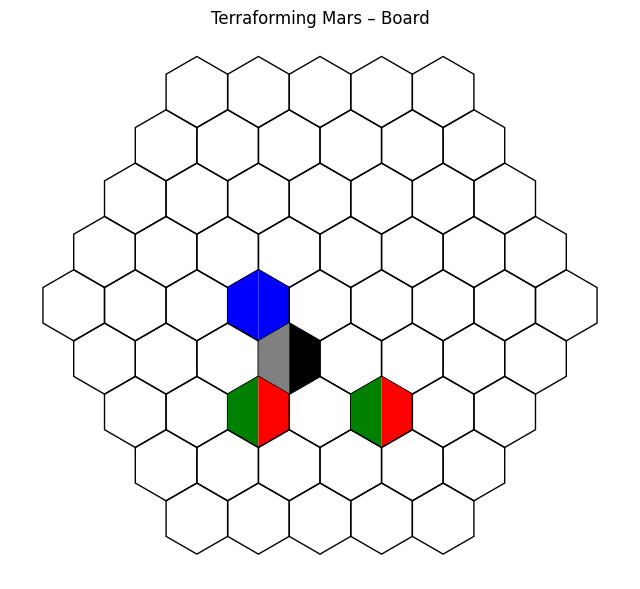

In [ ]:
map_model.draw()